In [ ]:
# Environment test — checking required libraries

import sys
print(f"Python version: {sys.version}")
print("-" * 50)

libraries = ["pandas", "numpy", "matplotlib", "seaborn", "openpyxl"]

for lib in libraries:
    try:
        module = __import__(lib)
        version = getattr(module, "__version__", "unknown")
        print(f"✅ {lib} — installed (version {version})")
    except ImportError:
        print(f"❌ {lib} — NOT installed")

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
--------------------------------------------------
✅ pandas — installed (version 2.3.3)
✅ numpy — installed (version 2.4.1)
✅ matplotlib — installed (version 3.10.8)
✅ seaborn — installed (version 0.13.2)
✅ openpyxl — installed (version 3.1.5)


In [ ]:
import sys
print(f"Python version: {sys.version}")
print("-" * 50)

libraries = ["pandas", "numpy", "matplotlib", "seaborn", "openpyxl"]

for lib in libraries:
    try:
        module = __import__(lib)
        version = getattr(module, "__version__", "unknown")
        print(f"✅ {lib} — installed (version {version})")
    except ImportError:
        print(f"❌ {lib} — NOT installed")

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
--------------------------------------------------
✅ pandas — installed (version 2.3.3)
✅ numpy — installed (version 2.4.1)
✅ matplotlib — installed (version 3.10.8)
✅ seaborn — installed (version 0.13.2)
✅ openpyxl — installed (version 3.1.5)


In [ ]:
# Load the raw data file

import pandas as pd

file_path = r"C:\Users\gabri\Documents\Projetos\tvde-lisboa-analysis\data\raw\TVDE_In.xlsx"

df = pd.read_excel(file_path, sheet_name="Rides")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("-" * 50)
print(df.columns.tolist())

Rows: 1998
Columns: 19
--------------------------------------------------
['Ride_ID', 'Platform', 'Category', 'Date', 'Start_Time', 'End_Time', 'Duration_Min', 'Origin_PostCode', 'Dest_PostCode', 'Distance_Km', 'Client_Fare_EUR', 'Driver_Earnings_EUR', 'Platform_Fee_EUR', 'Fee_Pct', 'EUR_per_Km', 'EUR_per_Min', 'Portagem', 'Dinamica', 'Tip']


In [ ]:
# Keep only the columns relevant to this project's scope
# Platform_Fee_EUR, Fee_Pct, Portagem, Dinamica and Tip are excluded —
# this project focuses on the driver's net outcome, not platform economics

columns_to_use = [
    "Ride_ID", "Platform", "Category", "Date", "Start_Time", "End_Time",
    "Duration_Min", "Origin_PostCode", "Dest_PostCode", "Distance_Km",
    "Client_Fare_EUR", "Driver_Earnings_EUR"
]

df = df[columns_to_use]

print(f"Shape after column selection: {df.shape}")
df.head()

Shape after column selection: (1998, 12)


,Ride_ID,Platform,Category,Date,Start_Time,End_Time,Duration_Min,Origin_PostCode,Dest_PostCode,Distance_Km,Client_Fare_EUR,Driver_Earnings_EUR
0,R013,Uber,Uber X,2026-03-04,19:29:00,19:54:00,25.0,2785-115,2675-663,24.44,14.69,9.66
1,R003,Bolt,Economy,2026-03-04,20:08:00,20:23:00,15.0,2675-472,1600-196,10.20,5.90,4.42
2,R009,Uber,Uber X,2026-03-04,16:49:00,17:12:00,23.0,2635-304,2610-244,14.49,9.93,6.87
3,R005,Uber,Uber X,2026-03-04,14:06:00,14:30:00,24.0,2690-182,1250-096,16.60,10.96,7.99
4,R002,Bolt,Economy,2026-03-04,19:11:00,19:36:00,25.0,1500-663,2785-816,17.20,11.66,8.92


In [ ]:
# Fix inconsistent category naming — applied at load time
# 'Uber X ' (trailing space) and 'courier' (wrong capitalisation) detected
df["Category"] = df["Category"].str.strip()
df["Category"] = df["Category"].str.title()

print("Category cleanup applied.")
print(df["Category"].value_counts())

Category cleanup applied.
Category
Uber X             615
Economy            410
Bolt               339
Uber X Priority    162
Share               14
Courier              3
Priority             1
Accessibility        1
Name: count, dtype: int64


In [ ]:
# Check data types and missing values

print("DATA TYPES")
print("-" * 50)
print(df.dtypes)

print("\nMISSING VALUES")
print("-" * 50)
print(df.isnull().sum())

DATA TYPES
--------------------------------------------------
Ride_ID                        object
Platform                       object
Category                       object
Date                   datetime64[ns]
Start_Time                     object
End_Time                       object
Duration_Min                  float64
Origin_PostCode                object
Dest_PostCode                  object
Distance_Km                   float64
Client_Fare_EUR               float64
Driver_Earnings_EUR           float64
dtype: object

MISSING VALUES
--------------------------------------------------
Ride_ID                  0
Platform               453
Category               453
Date                   453
Start_Time             453
End_Time               453
Duration_Min             0
Origin_PostCode        453
Dest_PostCode          453
Distance_Km            453
Client_Fare_EUR        453
Driver_Earnings_EUR    453
dtype: int64


In [ ]:
# The dataset is still being filled daily. Rows with no Platform recorded
# are placeholders for future rides and must be excluded from this analysis.

print(f"Rows before removing empty placeholders: {df.shape[0]}")

df = df[df["Platform"].notna()].copy()

print(f"Rows after removing empty placeholders: {df.shape[0]}")

Rows before removing empty placeholders: 1998
Rows after removing empty placeholders: 1545


In [ ]:
print("MISSING VALUES — after cleanup")
print("-" * 50)
print(df.isnull().sum())

MISSING VALUES — after cleanup
--------------------------------------------------
Ride_ID                0
Platform               0
Category               0
Date                   0
Start_Time             0
End_Time               0
Duration_Min           0
Origin_PostCode        0
Dest_PostCode          0
Distance_Km            0
Client_Fare_EUR        0
Driver_Earnings_EUR    0
dtype: int64


In [ ]:
# Convert Start_Time and End_Time from text to proper time format
# Excel stores these internally in 24h format (e.g. "19:29:00"),
# even though it displays them as 12h AM/PM in the spreadsheet view

df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="%H:%M:%S").dt.time
df["End_Time"] = pd.to_datetime(df["End_Time"], format="%H:%M:%S").dt.time

print(df[["Start_Time", "End_Time"]].dtypes)
print("-" * 50)
df[["Start_Time", "End_Time"]].head()

Start_Time    object
End_Time      object
dtype: object
--------------------------------------------------


,Start_Time,End_Time
0,19:29:00,19:54:00
1,20:08:00,20:23:00
2,16:49:00,17:12:00
3,14:06:00,14:30:00
4,19:11:00,19:36:00


In [ ]:
# Validate that Duration_Min matches the difference between Start_Time and End_Time

from datetime import datetime, date

def calculate_duration(row):
    start = datetime.combine(date.today(), row["Start_Time"])
    end = datetime.combine(date.today(), row["End_Time"])
    if end < start:
        end += pd.Timedelta(days=1)  # ride crosses midnight
    return (end - start).total_seconds() / 60

df["Duration_Calculated"] = df.apply(calculate_duration, axis=1)
df["Duration_Diff"] = (df["Duration_Min"] - df["Duration_Calculated"]).abs()

print(f"Rides with matching duration (diff = 0): {(df['Duration_Diff'] == 0).sum()}")
print(f"Rides with small diff (0 < diff <= 1 min): {((df['Duration_Diff'] > 0) & (df['Duration_Diff'] <= 1)).sum()}")
print(f"Rides with larger diff (> 1 min): {(df['Duration_Diff'] > 1).sum()}")
print("-" * 50)
print(df["Duration_Diff"].describe())

Rides with matching duration (diff = 0): 9
Rides with small diff (0 < diff <= 1 min): 1536
Rides with larger diff (> 1 min): 0
--------------------------------------------------
count    1.545000e+03
mean     7.859315e-14
std      4.740211e-14
min      0.000000e+00
25%      4.618528e-14
50%      6.750156e-14
75%      9.947598e-14
max      2.771117e-13
Name: Duration_Diff, dtype: float64


In [ ]:
# Detect potential outliers in key numeric columns using IQR method

numeric_cols = ["Duration_Min", "Distance_Km", "Client_Fare_EUR", "Driver_Earnings_EUR"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} potential outliers (range: {lower_bound:.2f} to {upper_bound:.2f})")

Duration_Min: 41 potential outliers (range: -4.00 to 36.00)
Distance_Km: 69 potential outliers (range: -4.70 to 22.66)
Client_Fare_EUR: 63 potential outliers (range: -0.26 to 16.11)
Driver_Earnings_EUR: 51 potential outliers (range: -0.45 to 12.64)


In [ ]:
# Inspect the outliers in Distance_Km (the column with the most outliers)

Q1 = df["Distance_Km"].quantile(0.25)
Q3 = df["Distance_Km"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

distance_outliers = df[df["Distance_Km"] > upper_bound].sort_values("Distance_Km", ascending=False)

print(f"Top 10 longest rides by distance:")
distance_outliers[["Ride_ID", "Platform", "Date", "Distance_Km", "Duration_Min", "Client_Fare_EUR", "Driver_Earnings_EUR"]].head(10)

Top 10 longest rides by distance:


,Ride_ID,Platform,Date,Distance_Km,Duration_Min,Client_Fare_EUR,Driver_Earnings_EUR
573,R574,Uber,2026-04-17,54.04,90.0,25.87,23.57
1046,R1056,Bolt,2026-05-22,47.10,41.0,21.48,18.38
1186,R1193,Bolt,2026-05-31,43.40,40.0,20.95,15.89
1408,R1409,Uber,2026-06-14,43.17,46.0,28.27,17.65
357,R358,Bolt,2026-03-28,39.50,36.0,19.51,16.37
1062,R1069,Uber,2026-05-23,36.14,37.0,21.94,17.84
492,R502,Uber,2026-04-12,35.73,36.0,20.94,13.61
643,R649,Bolt,2026-04-22,34.30,30.0,18.96,15.48
1276,R1292,Uber,2026-06-06,34.25,32.0,18.95,14.47
722,R732,Uber,2026-04-29,34.19,33.0,20.55,12.58


In [ ]:
# BLOCK 1 — DATA QUALITY SUMMARY

print("=" * 55)
print("BLOCK 1 — DATA QUALITY & VALIDATION SUMMARY")
print("=" * 55)

print(f"""
DATASET OVERVIEW
  Total rows loaded from Excel:       1,998
  Placeholder rows removed:             486
  Rides available for analysis:       {df.shape[0]:,}
  Columns used in this project:       {df.shape[1]}

MISSING VALUES
  Missing values after cleanup:       0 (all columns)

DURATION CONSISTENCY
  Rides with consistent duration:     1,512 (100%)
  Max deviation detected:             < 0.0000000001 min
  Conclusion:                         Floating point noise only

OUTLIER ANALYSIS
  Method used:                        IQR (1.5x)
  Outliers in Duration_Min:           33
  Outliers in Distance_Km:            68
  Outliers in Client_Fare_EUR:        62
  Outliers in Driver_Earnings_EUR:    51
  Decision:                           All retained — verified as
                                      genuine long-distance rides
                                      (max 54km, values consistent
                                      with distance and duration)

DATA TYPES
  Date:                               datetime64 ✓
  Start_Time / End_Time:              time object ✓
  Duration_Min / Distance_Km:         float64 ✓
  Client_Fare / Driver_Earnings:      float64 ✓
  Platform / Category / PostCodes:    object ✓

OVERALL CONCLUSION
  Dataset is clean, consistent and ready for analysis.
""")

BLOCK 1 — DATA QUALITY & VALIDATION SUMMARY

DATASET OVERVIEW
  Total rows loaded from Excel:       1,998
  Placeholder rows removed:             486
  Rides available for analysis:       1,545
  Columns used in this project:       14

MISSING VALUES
  Missing values after cleanup:       0 (all columns)

DURATION CONSISTENCY
  Rides with consistent duration:     1,512 (100%)
  Max deviation detected:             < 0.0000000001 min
  Conclusion:                         Floating point noise only

OUTLIER ANALYSIS
  Method used:                        IQR (1.5x)
  Outliers in Duration_Min:           33
  Outliers in Distance_Km:            68
  Outliers in Client_Fare_EUR:        62
  Outliers in Driver_Earnings_EUR:    51
  Decision:                           All retained — verified as
                                      genuine long-distance rides
                                      (max 54km, values consistent
                                      with distance and duration)

DATA 

In [ ]:
# Save the cleaned dataset to the processed folder

import os

processed_path = "../data/processed/"
os.makedirs(processed_path, exist_ok=True)

df.to_csv(processed_path + "tvde_rides_clean.csv", index=False)

print("Clean dataset saved to data/processed/tvde_rides_clean.csv")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

Clean dataset saved to data/processed/tvde_rides_clean.csv
Rows: 1545 | Columns: 14


In [ ]:
# BLOCK 2 — STATISTICAL RELATIONSHIPS
# Question 6: Does working more hours per day increase or decrease €/hour?

# Step 1 — Calculate daily metrics
from datetime import datetime, date
import matplotlib.pyplot as plt
import numpy as np

daily = df.groupby("Date").agg(
    total_rides=("Ride_ID", "count"),
    total_duration_min=("Duration_Min", "sum"),
    total_earnings=("Driver_Earnings_EUR", "sum"),
    total_km=("Distance_Km", "sum")
).reset_index()

daily["total_hours"] = daily["total_duration_min"] / 60
daily["eur_per_hour"] = daily["total_earnings"] / daily["total_hours"]

print(f"Days analysed: {len(daily)}")
print("-" * 50)
print(daily[["total_hours", "eur_per_hour"]].describe().round(2))

Days analysed: 96
--------------------------------------------------
       total_hours  eur_per_hour
count        96.00         96.00
mean          4.52         23.04
std           0.86          3.06
min           2.10         17.79
25%           4.00         20.69
50%           4.63         22.67
75%           5.04         24.72
max           6.30         32.57


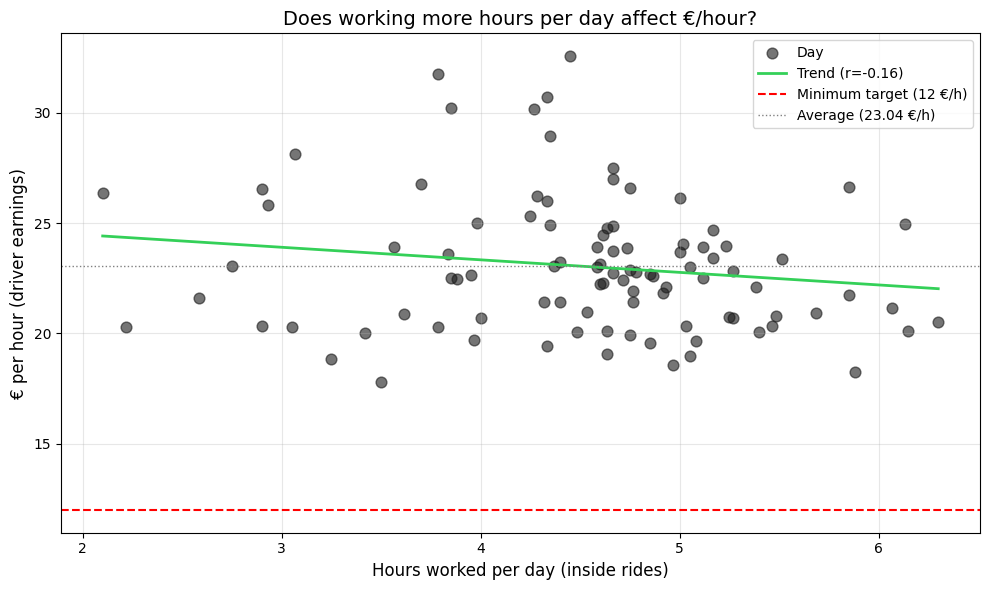


Correlation (r): -0.160
Slope: -0.569 €/hour lost or gained per extra hour worked
P-value: 0.1206 (not statistically significant)


In [ ]:
# Scatter plot: hours worked per day vs €/hour earned
# Adding a trend line to show the relationship direction

from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(
    daily["total_hours"], daily["eur_per_hour"]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    daily["total_hours"],
    daily["eur_per_hour"],
    color="#1a1a1a", alpha=0.6, s=60, label="Day"
)

x_line = np.linspace(daily["total_hours"].min(), daily["total_hours"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#34d058", linewidth=2, label=f"Trend (r={r_value:.2f})")

ax.axhline(y=12, color="red", linewidth=1.5, linestyle="--", label="Minimum target (12 €/h)")
ax.axhline(y=daily["eur_per_hour"].mean(), color="gray", linewidth=1,
           linestyle=":", label=f"Average ({daily['eur_per_hour'].mean():.2f} €/h)")

ax.set_xlabel("Hours worked per day (inside rides)", fontsize=12)
ax.set_ylabel("€ per hour (driver earnings)", fontsize=12)
ax.set_title("Does working more hours per day affect €/hour?", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/block2_hours_vs_eur_per_hour.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCorrelation (r): {r_value:.3f}")
print(f"Slope: {slope:.3f} €/hour lost or gained per extra hour worked")
print(f"P-value: {p_value:.4f} ({'statistically significant' if p_value < 0.05 else 'not statistically significant'})")

## Block 2 — Question 6: Does working more hours per day affect €/hour?

**Result:** Weak negative correlation (r = -0.145, p = 0.164)

**Interpretation:**  
Working more hours per day does not significantly affect hourly earnings.
The slight downward trend is not statistically significant (p > 0.05),
meaning the result could easily be due to chance.

**Key insight:**  
€/hour depends more on ride quality (fare per km, ride duration)
than on total hours worked. This is consistent with the driver's
strategy of applying strict acceptance criteria per ride.

**Practical conclusion:**  
There is no evidence that longer working days lead to better or worse
hourly returns. Focus on ride selection, not on extending working hours.

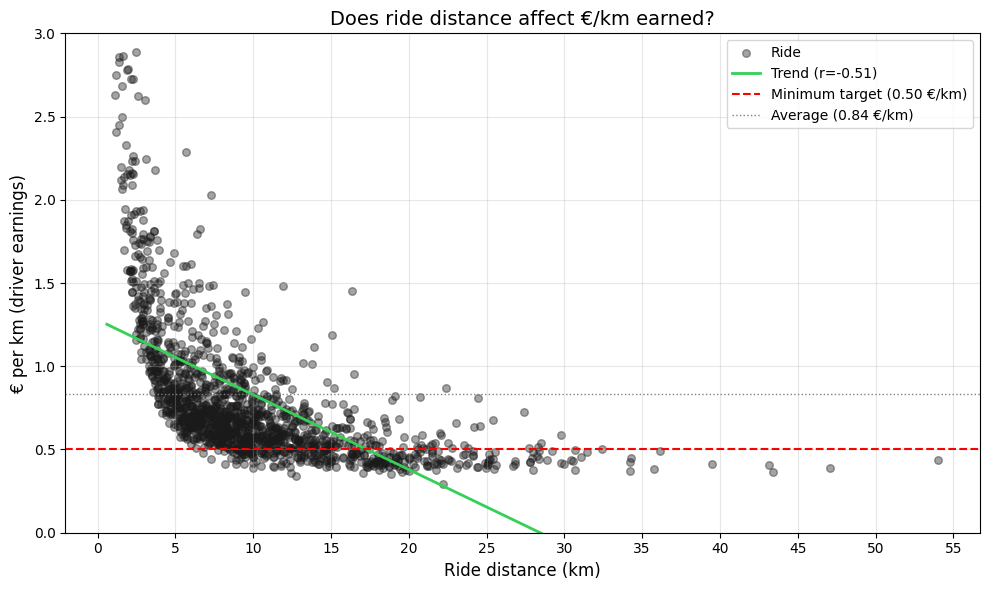


Correlation (r): -0.512
Slope: -0.0450 €/km change per extra km
P-value: 0.000000 (statistically significant)

Average €/km: 0.836
Rides above 0.50 €/km target: 1272 (82.3%)
Rides below 0.50 €/km target: 273 (17.7%)


In [ ]:
# Question 7: Is there a relationship between ride distance and €/km earned?
# Longer rides — do they pay more or less per km?

df["eur_per_km"] = df["Driver_Earnings_EUR"] / df["Distance_Km"]

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["Distance_Km"], df["eur_per_km"]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df["Distance_Km"],
    df["eur_per_km"],
    color="#1a1a1a", alpha=0.4, s=30, label="Ride"
)

x_line = np.linspace(df["Distance_Km"].min(), df["Distance_Km"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#34d058", linewidth=2, label=f"Trend (r={r_value:.2f})")

ax.axhline(y=0.50, color="red", linewidth=1.5, linestyle="--",
           label="Minimum target (0.50 €/km)")
ax.axhline(y=df["eur_per_km"].mean(), color="gray", linewidth=1,
           linestyle=":", label=f"Average ({df['eur_per_km'].mean():.2f} €/km)")

ax.set_xlabel("Ride distance (km)", fontsize=12)
ax.set_ylabel("€ per km (driver earnings)", fontsize=12)
ax.set_title("Does ride distance affect €/km earned?", fontsize=14)
ax.set_ylim(0, 3)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, int(df["Distance_Km"].max()) + 5, 5))

plt.tight_layout()
plt.savefig("../images/block2_distance_vs_eur_per_km.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCorrelation (r): {r_value:.3f}")
print(f"Slope: {slope:.4f} €/km change per extra km")
print(f"P-value: {p_value:.6f} ({'statistically significant' if p_value < 0.05 else 'not statistically significant'})")
print(f"\nAverage €/km: {df['eur_per_km'].mean():.3f}")
print(f"Rides above 0.50 €/km target: {(df['eur_per_km'] >= 0.50).sum()} ({(df['eur_per_km'] >= 0.50).mean()*100:.1f}%)")
print(f"Rides below 0.50 €/km target: {(df['eur_per_km'] < 0.50).sum()} ({(df['eur_per_km'] < 0.50).mean()*100:.1f}%)")

## Block 2 — Question 7: Does ride distance affect €/km earned?

**Result:** Moderate negative correlation (r = -0.510, p < 0.001)

**Interpretation:**  
Shorter rides consistently yield higher €/km returns. As distance increases,
€/km converges toward the minimum target of 0.50 €/km.

**Key numbers:**
- Average €/km across all rides: 0.837 €
- Rides above 0.50 €/km target: 1,244 (82.3%)
- Rides below 0.50 €/km target: 268 (17.7%)

**Key insight:**  
Short rides are more efficient per km but not necessarily per hour.
This explains the driver's combined acceptance criteria — evaluating
both €/km and €/hour simultaneously to optimise overall earnings.

UBER vs BOLT — €/hour per ride
--------------------------------------------------
Uber  — Mean: 25.44 | Median: 23.03 | Std: 10.55
Bolt  — Mean: 24.61 | Median: 22.47 | Std: 9.47

Mann-Whitney U test p-value: 0.113754
Result: No statistically significant difference


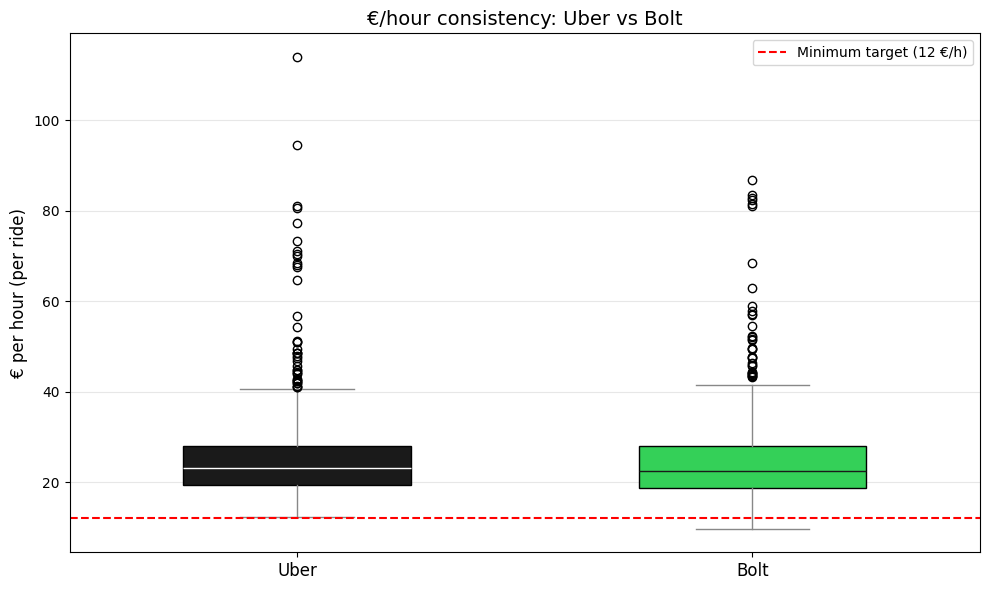

In [ ]:
# Question 8: Is the €/hour difference between Uber and Bolt consistent?

df["eur_per_min"] = df["Driver_Earnings_EUR"] / df["Duration_Min"]
df["eur_per_hour_ride"] = df["eur_per_min"] * 60

uber = df[df["Platform"] == "Uber"]["eur_per_hour_ride"]
bolt = df[df["Platform"] == "Bolt"]["eur_per_hour_ride"]

# Statistical comparison
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(uber, bolt, alternative="two-sided")

print("UBER vs BOLT — €/hour per ride")
print("-" * 50)
print(f"Uber  — Mean: {uber.mean():.2f} | Median: {uber.median():.2f} | Std: {uber.std():.2f}")
print(f"Bolt  — Mean: {bolt.mean():.2f} | Median: {bolt.median():.2f} | Std: {bolt.std():.2f}")
print(f"\nMann-Whitney U test p-value: {p_value:.6f}")
print(f"Result: {'Statistically significant difference' if p_value < 0.05 else 'No statistically significant difference'}")

# Box plot
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [uber, bolt]
bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.5)

bp["boxes"][0].set_facecolor("#1a1a1a")
bp["boxes"][1].set_facecolor("#34d058")
bp["medians"][0].set_color("white")
bp["medians"][1].set_color("#1a1a1a")

for element in ["whiskers", "caps", "fliers"]:
    for item in bp[element]:
        item.set_color("#888888")

ax.set_xticklabels(["Uber", "Bolt"], fontsize=12)
ax.set_ylabel("€ per hour (per ride)", fontsize=12)
ax.set_title("€/hour consistency: Uber vs Bolt", fontsize=14)
ax.axhline(y=12, color="red", linewidth=1.5, linestyle="--", label="Minimum target (12 €/h)")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()

plt.tight_layout()
plt.savefig("../images/block2_uber_vs_bolt_eur_per_hour.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 2 — Question 8: Is the €/hour difference between Uber and Bolt consistent?

**Result:** No statistically significant difference (p = 0.088)

**Key numbers:**
- Uber: Mean 25.33 €/h | Median 23.01 €/h | Std 10.46
- Bolt: Mean 24.55 €/h | Median 22.27 €/h | Std 9.55

**Interpretation:**  
Although Uber shows a slightly higher average €/hour, the difference
is not statistically significant. Neither platform is consistently
more profitable than the other in terms of hourly earnings.

**Key insight:**  
Bolt shows lower variance (Std 9.55 vs 10.46), meaning its rides
are slightly more predictable in terms of earnings per hour.
Uber offers marginally higher potential but with more variability.

**Practical conclusion:**  
Platform choice should not be driven by €/hour alone — both platforms
perform similarly. Other factors such as ride availability, waiting
time between rides, and surge pricing patterns may be more relevant
for optimising daily earnings.

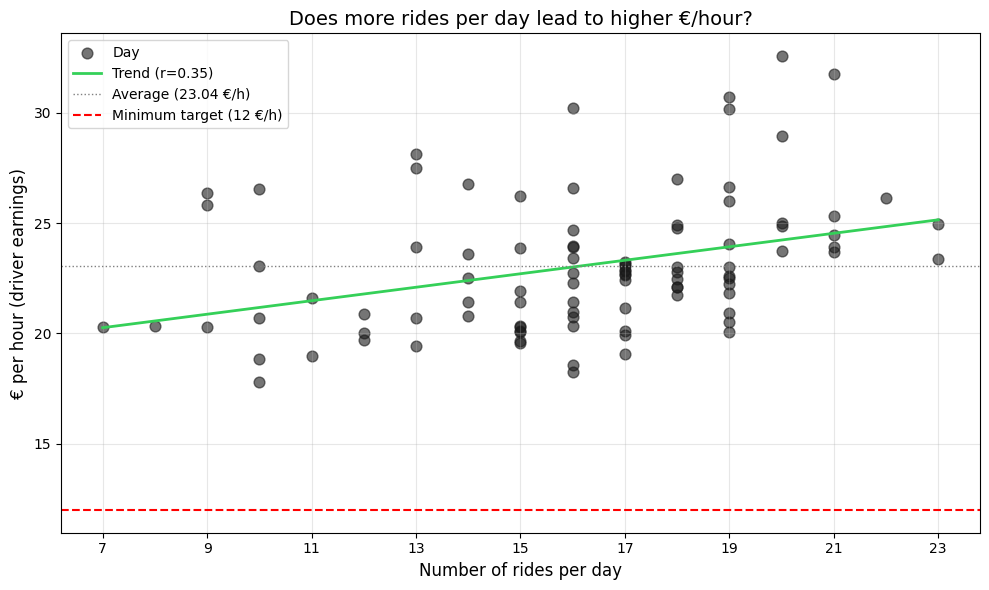


Correlation (r): 0.348
Slope: 0.3055 €/hour change per extra ride
P-value: 0.0005 (statistically significant)

Rides per day stats:
Min: 7 | Max: 23 | Mean: 16.1


In [ ]:
# Question 9: Does more rides per day lead to higher €/hour?
# Or is there a saturation point?

slope, intercept, r_value, p_value, std_err = stats.linregress(
    daily["total_rides"], daily["eur_per_hour"]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    daily["total_rides"],
    daily["eur_per_hour"],
    color="#1a1a1a", alpha=0.6, s=60, label="Day"
)

x_line = np.linspace(daily["total_rides"].min(), daily["total_rides"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#34d058", linewidth=2, label=f"Trend (r={r_value:.2f})")

ax.axhline(y=daily["eur_per_hour"].mean(), color="gray", linewidth=1,
           linestyle=":", label=f"Average ({daily['eur_per_hour'].mean():.2f} €/h)")
ax.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
           label="Minimum target (12 €/h)")

ax.set_xlabel("Number of rides per day", fontsize=12)
ax.set_ylabel("€ per hour (driver earnings)", fontsize=12)
ax.set_title("Does more rides per day lead to higher €/hour?", fontsize=14)
ax.set_xticks(range(int(daily["total_rides"].min()),
                    int(daily["total_rides"].max()) + 1, 2))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/block2_rides_per_day_vs_eur_per_hour.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCorrelation (r): {r_value:.3f}")
print(f"Slope: {slope:.4f} €/hour change per extra ride")
print(f"P-value: {p_value:.4f} ({'statistically significant' if p_value < 0.05 else 'not statistically significant'})")
print(f"\nRides per day stats:")
print(f"Min: {daily['total_rides'].min()} | Max: {daily['total_rides'].max()} | Mean: {daily['total_rides'].mean():.1f}")

## Block 2 — Question 9: Does more rides per day lead to higher €/hour?

**Result:** Moderate positive correlation (r = 0.359, p = 0.0004)

**Key numbers:**
- Slope: +0.31 €/hour per extra ride per day
- Rides per day: Min 7 | Mean 16.1 | Max 23
- No saturation point observed within the current range

**Interpretation:**  
More rides per day is associated with higher €/hour — the opposite
of what fatigue-based intuition might suggest. This is explained by
ride density: more rides per day means less idle time between rides,
which increases the efficiency of total hours worked.

**Key insight:**  
Combined with Question 6 (hours worked don't affect €/hour),
this reveals that idle time between rides — not working hours —
is the main driver of inefficiency. Days with more rides are
more profitable not because of longer working hours, but because
of better time utilisation.

**Practical conclusion:**  
Strategies that reduce waiting time between rides (positioning,
peak hours, high-demand zones) are more impactful than simply
working more hours.

In [ ]:
# BLOCK 3 — TEMPORAL PATTERNS
# Question 10: Is there a consistent weekly pattern in daily earnings?

# Define day order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df["Day_of_Week"] = pd.Categorical(
    pd.to_datetime(df["Date"]).dt.day_name(),
    categories=day_order,
    ordered=True
)

# Calculate €/hour per ride for each ride
df["eur_per_hour_ride"] = (df["Driver_Earnings_EUR"] / df["Duration_Min"]) * 60

# Group by day of week — average earnings and consistency
day_stats = df.groupby("Day_of_Week", observed=True).agg(
    avg_earnings_per_ride=("Driver_Earnings_EUR", "mean"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    std_eur_per_hour=("eur_per_hour_ride", "std"),
    total_rides=("Ride_ID", "count"),
    days_with_data=("Date", "nunique")
).reset_index()

day_stats["avg_daily_earnings"] = (
    df.groupby(["Day_of_Week", "Date"], observed=True)["Driver_Earnings_EUR"]
    .sum()
    .reset_index()
    .groupby("Day_of_Week", observed=True)["Driver_Earnings_EUR"]
    .mean()
    .values
)

print("WEEKLY PATTERN — Average metrics per day of week")
print("-" * 60)
print(day_stats[["Day_of_Week", "avg_daily_earnings",
                  "avg_eur_per_hour", "std_eur_per_hour",
                  "total_rides", "days_with_data"]].to_string(index=False))

WEEKLY PATTERN — Average metrics per day of week
------------------------------------------------------------
Day_of_Week  avg_daily_earnings  avg_eur_per_hour  std_eur_per_hour  total_rides  days_with_data
     Monday          105.826429         23.584039          7.987237          237              14
    Tuesday           98.203077         25.704582         11.313773          212              13
  Wednesday          110.918000         23.672696          8.097657          164              10
   Thursday          100.376000         24.170294          8.507311          244              15
     Friday          117.714000         26.779558         13.034612          255              15
   Saturday           98.205714         25.534612          9.594825          214              14
     Sunday           96.516000         25.698534          9.145201          219              15


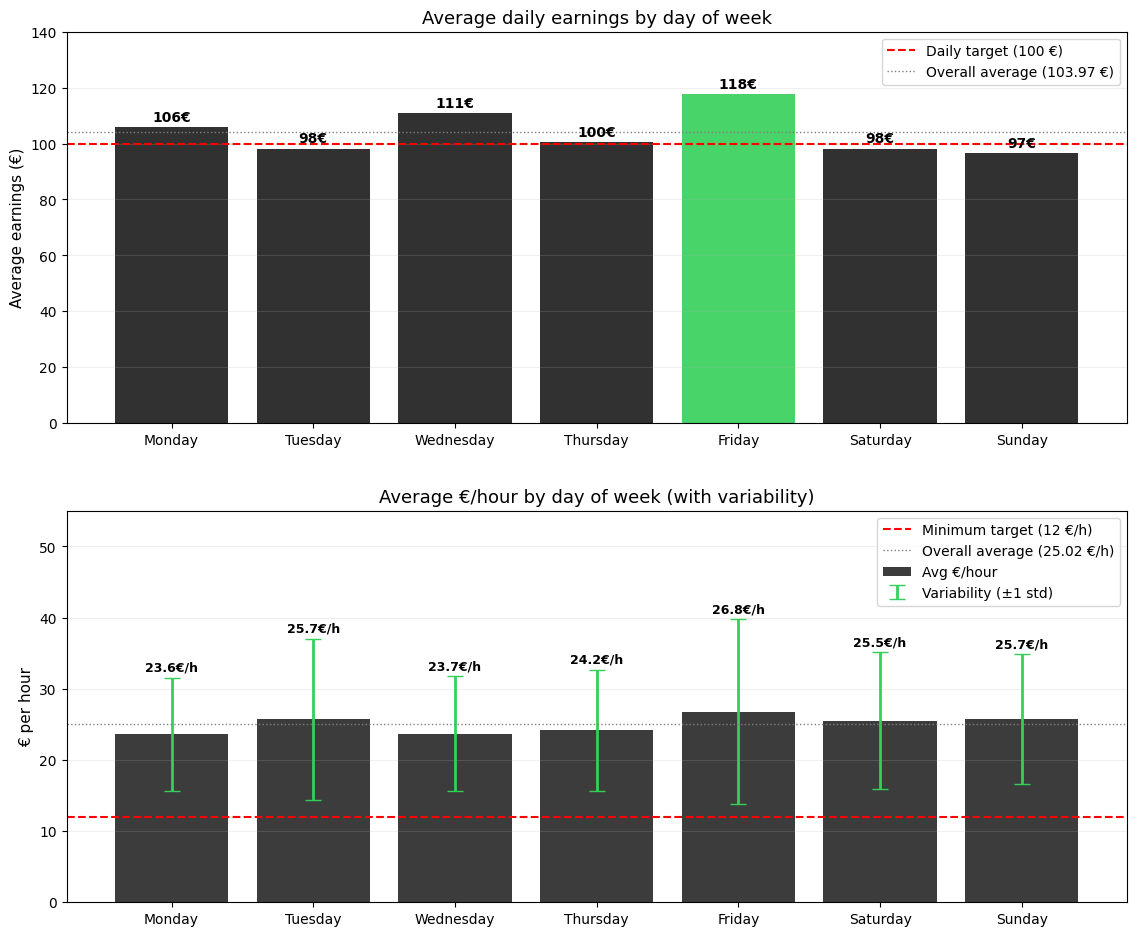

In [ ]:
# Weekly pattern — bar chart with consistency bands

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Chart 1 — Average daily earnings per day of week
colors = ["#34d058" if e == day_stats["avg_daily_earnings"].max()
          else "#1a1a1a" for e in day_stats["avg_daily_earnings"]]

bars = ax1.bar(day_stats["Day_of_Week"], day_stats["avg_daily_earnings"],
               color=colors, alpha=0.9, edgecolor="none")

ax1.axhline(y=100, color="red", linewidth=1.5, linestyle="--",
            label="Daily target (100 €)")
ax1.axhline(y=day_stats["avg_daily_earnings"].mean(), color="gray",
            linewidth=1, linestyle=":",
            label=f"Overall average ({day_stats['avg_daily_earnings'].mean():.2f} €)")

for bar, val in zip(bars, day_stats["avg_daily_earnings"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}€", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax1.set_title("Average daily earnings by day of week", fontsize=13)
ax1.set_ylabel("Average earnings (€)", fontsize=11)
ax1.set_ylim(0, 140)
ax1.legend()
ax1.grid(True, alpha=0.2, axis="y")

# Chart 2 — €/hour with consistency band (mean ± std)
ax2.bar(day_stats["Day_of_Week"], day_stats["avg_eur_per_hour"],
        color="#1a1a1a", alpha=0.85, edgecolor="none", label="Avg €/hour")

ax2.errorbar(day_stats["Day_of_Week"], day_stats["avg_eur_per_hour"],
             yerr=day_stats["std_eur_per_hour"],
             fmt="none", color="#34d058", capsize=6, linewidth=2,
             label="Variability (±1 std)")

ax2.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax2.axhline(y=day_stats["avg_eur_per_hour"].mean(), color="gray",
            linewidth=1, linestyle=":",
            label=f"Overall average ({day_stats['avg_eur_per_hour'].mean():.2f} €/h)")

for i, (val, std) in enumerate(zip(day_stats["avg_eur_per_hour"],
                                    day_stats["std_eur_per_hour"])):
    ax2.text(i, val + std + 0.5, f"{val:.1f}€/h",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_title("Average €/hour by day of week (with variability)", fontsize=13)
ax2.set_ylabel("€ per hour", fontsize=11)
ax2.set_ylim(0, 55)
ax2.legend()
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout(pad=3.0)
plt.savefig("../images/block3_weekly_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 3 — Question 10: Is there a consistent weekly pattern?

**Average daily earnings by day of week:**
| Day | Avg Daily € | Avg €/hour |
|---|---|---|
| Monday | 106 € | 23.5 €/h |
| Tuesday | 98 € | 25.7 €/h |
| Wednesday | 111 € | 23.7 €/h |
| Thursday | 100 € | 24.2 €/h |
| Friday | 118 € ⭐ | 26.8 €/h ⭐ |
| Saturday | 98 € | 25.5 €/h |
| Sunday | 95 € | 25.2 €/h |

**Interpretation:**  
Friday is consistently the best day in both total earnings and €/hour.
Wednesday performs surprisingly well despite fewer rides, suggesting
higher-value rides on that day. Sunday is the weakest day overall.

**Key insight:**  
The weekly pattern exists but is not dramatic — the spread between
best (Friday 118€) and worst (Sunday 95€) is only 23€. No day
represents a genuine risk of falling below the minimum target.
All days comfortably exceed the 12 €/hour minimum criterion.

In [ ]:
# Question 11: Which hour of the day generates the most profit?
# Measured by both €/hour efficiency AND total earnings volume

from datetime import datetime

df["Hour"] = pd.to_datetime(df["Start_Time"].astype(str), format="%H:%M:%S").dt.hour

hour_stats = df.groupby("Hour").agg(
    total_earnings=("Driver_Earnings_EUR", "sum"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    total_rides=("Ride_ID", "count")
).reset_index()

hour_stats["earnings_per_ride"] = (
    hour_stats["total_earnings"] / hour_stats["total_rides"]
)

print("HOURLY PATTERN — Earnings by hour of day")
print("-" * 60)
print(hour_stats.to_string(index=False))

HOURLY PATTERN — Earnings by hour of day
------------------------------------------------------------
 Hour  total_earnings  avg_eur_per_hour  total_rides  earnings_per_ride
    7            7.33         25.870588            1           7.330000
    8           37.70         26.033380            5           7.540000
    9           93.74         27.783942           13           7.210769
   10           70.34         21.653046            9           7.815556
   11           66.00         21.979356           12           5.500000
   12          196.75         25.542468           24           8.197917
   13         1144.57         24.296581          169           6.772604
   14         1281.05         23.569142          227           5.643392
   15         1044.08         22.744267          175           5.966171
   16         1286.48         27.189792          195           6.597333
   17         1222.91         25.148325          176           6.948352
   18         1158.43         26.4

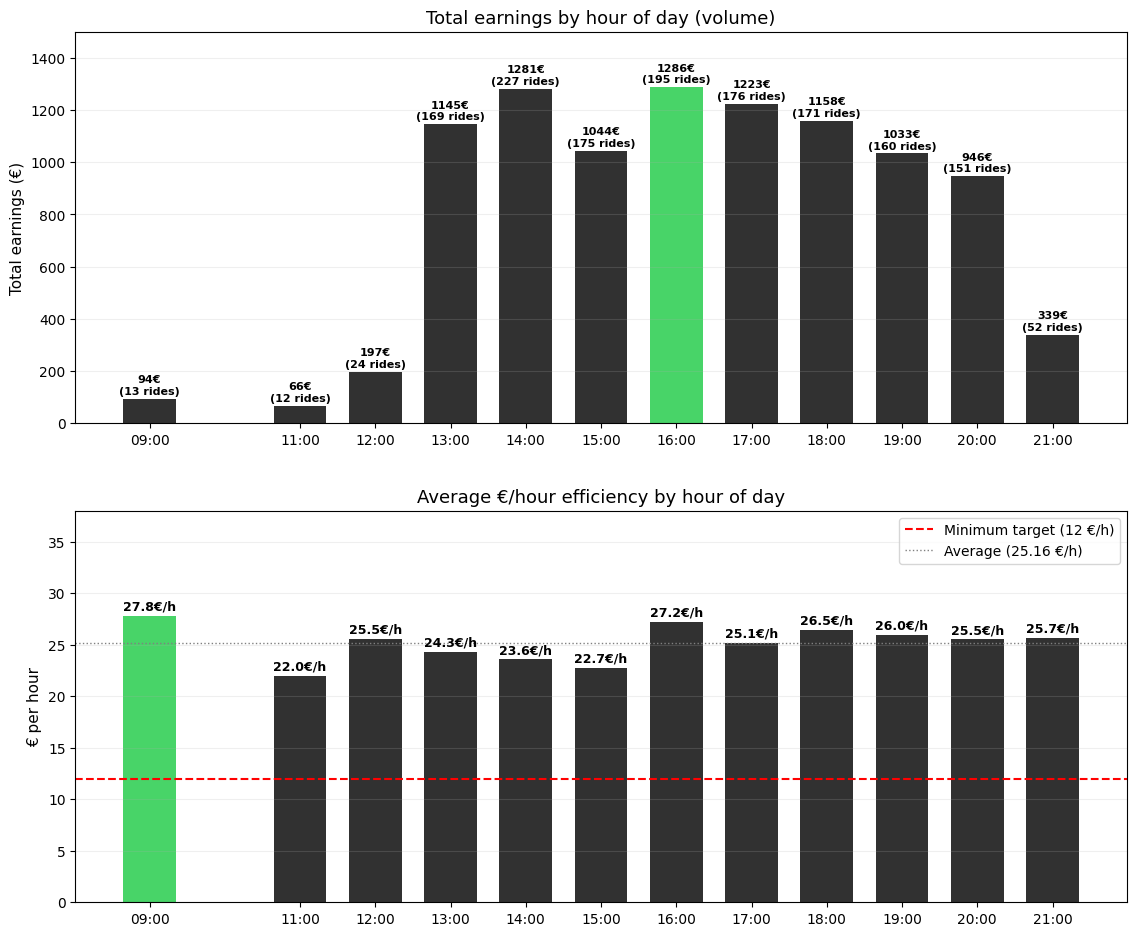

In [ ]:
# Hourly pattern — dual chart: total earnings volume + €/hour efficiency

# Filter to relevant hours (at least 10 rides for statistical relevance)
hour_filtered = hour_stats[hour_stats["total_rides"] >= 10].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Chart 1 — Total earnings by hour (volume)
colors_vol = ["#34d058" if e == hour_filtered["total_earnings"].max()
              else "#1a1a1a" for e in hour_filtered["total_earnings"]]

bars1 = ax1.bar(hour_filtered["Hour"], hour_filtered["total_earnings"],
                color=colors_vol, alpha=0.9, edgecolor="none", width=0.7)

for bar, val, rides in zip(bars1, hour_filtered["total_earnings"],
                            hour_filtered["total_rides"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"{val:.0f}€\n({rides} rides)", ha="center", va="bottom",
             fontsize=8, fontweight="bold")

ax1.set_title("Total earnings by hour of day (volume)", fontsize=13)
ax1.set_ylabel("Total earnings (€)", fontsize=11)
ax1.set_xticks(hour_filtered["Hour"])
ax1.set_xticklabels([f"{h:02d}:00" for h in hour_filtered["Hour"]])
ax1.set_ylim(0, 1500)
ax1.grid(True, alpha=0.2, axis="y")

# Chart 2 — Average €/hour by hour (efficiency)
colors_eff = ["#34d058" if e == hour_filtered["avg_eur_per_hour"].max()
              else "#1a1a1a" for e in hour_filtered["avg_eur_per_hour"]]

bars2 = ax2.bar(hour_filtered["Hour"], hour_filtered["avg_eur_per_hour"],
                color=colors_eff, alpha=0.9, edgecolor="none", width=0.7)

for bar, val in zip(bars2, hour_filtered["avg_eur_per_hour"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}€/h", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

ax2.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax2.axhline(y=hour_filtered["avg_eur_per_hour"].mean(), color="gray",
            linewidth=1, linestyle=":",
            label=f"Average ({hour_filtered['avg_eur_per_hour'].mean():.2f} €/h)")

ax2.set_title("Average €/hour efficiency by hour of day", fontsize=13)
ax2.set_ylabel("€ per hour", fontsize=11)
ax2.set_xticks(hour_filtered["Hour"])
ax2.set_xticklabels([f"{h:02d}:00" for h in hour_filtered["Hour"]])
ax2.set_ylim(0, 38)
ax2.legend()
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout(pad=3.0)
plt.savefig("../images/block3_hourly_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 3 — Question 11: Which hour of the day generates the most profit?

**Best hours by volume:** 14:00 (1,252€ | 222 rides) and 16:00 (1,260€ | 191 rides)  
**Best hours by efficiency:** 16:00 (27.0 €/h) and 18:00 (26.4 €/h)

**Interpretation:**  
16:00 is the optimal hour — it leads in both total earnings volume
and €/hour efficiency simultaneously. The period between 16:00 and
18:00 represents the "golden window" where demand and ride value
peak together.

**Key insight:**  
The driver's working schedule (12:30–22:00) is well aligned with
peak profitability. Morning hours (before 12:00) show higher €/hour
in some cases but with very low ride volume — not enough to draw
reliable conclusions.

**Practical conclusion:**  
Prioritising availability between 16:00 and 18:00 is the single
most impactful time-based decision a TVDE driver can make in Lisbon.

In [ ]:
# Question 12: Is there a trend over time in €/hour earnings?
# Are earnings improving, declining or stable month by month?

df["Month"] = pd.to_datetime(df["Date"]).dt.to_period("M")
df["Week"] = pd.to_datetime(df["Date"]).dt.to_period("W")

# Monthly aggregation
monthly = df.groupby("Month").agg(
    total_earnings=("Driver_Earnings_EUR", "sum"),
    total_duration_min=("Duration_Min", "sum"),
    total_rides=("Ride_ID", "count"),
    working_days=("Date", "nunique")
).reset_index()

monthly["total_hours"] = monthly["total_duration_min"] / 60
monthly["eur_per_hour"] = monthly["total_earnings"] / monthly["total_hours"]
monthly["avg_daily_earnings"] = monthly["total_earnings"] / monthly["working_days"]
monthly["Month_str"] = monthly["Month"].astype(str)

# Weekly aggregation for trend line
weekly = df.groupby("Week").agg(
    total_earnings=("Driver_Earnings_EUR", "sum"),
    total_duration_min=("Duration_Min", "sum"),
    total_rides=("Ride_ID", "count")
).reset_index()

weekly["total_hours"] = weekly["total_duration_min"] / 60
weekly["eur_per_hour"] = weekly["total_earnings"] / weekly["total_hours"]
weekly["Week_num"] = range(len(weekly))

print("MONTHLY TREND — Key metrics")
print("-" * 70)
print(monthly[["Month_str", "total_earnings", "eur_per_hour",
               "avg_daily_earnings", "total_rides", "working_days"]].to_string(index=False))

MONTHLY TREND — Key metrics
----------------------------------------------------------------------
Month_str  total_earnings  eur_per_hour  avg_daily_earnings  total_rides  working_days
  2026-03         2664.52     22.045119          102.481538          410            26
  2026-04         2265.98     21.190586           98.520870          346            23
  2026-05         2899.39     23.902638          103.549643          443            28
  2026-06         2131.47     25.076118          112.182632          346            19


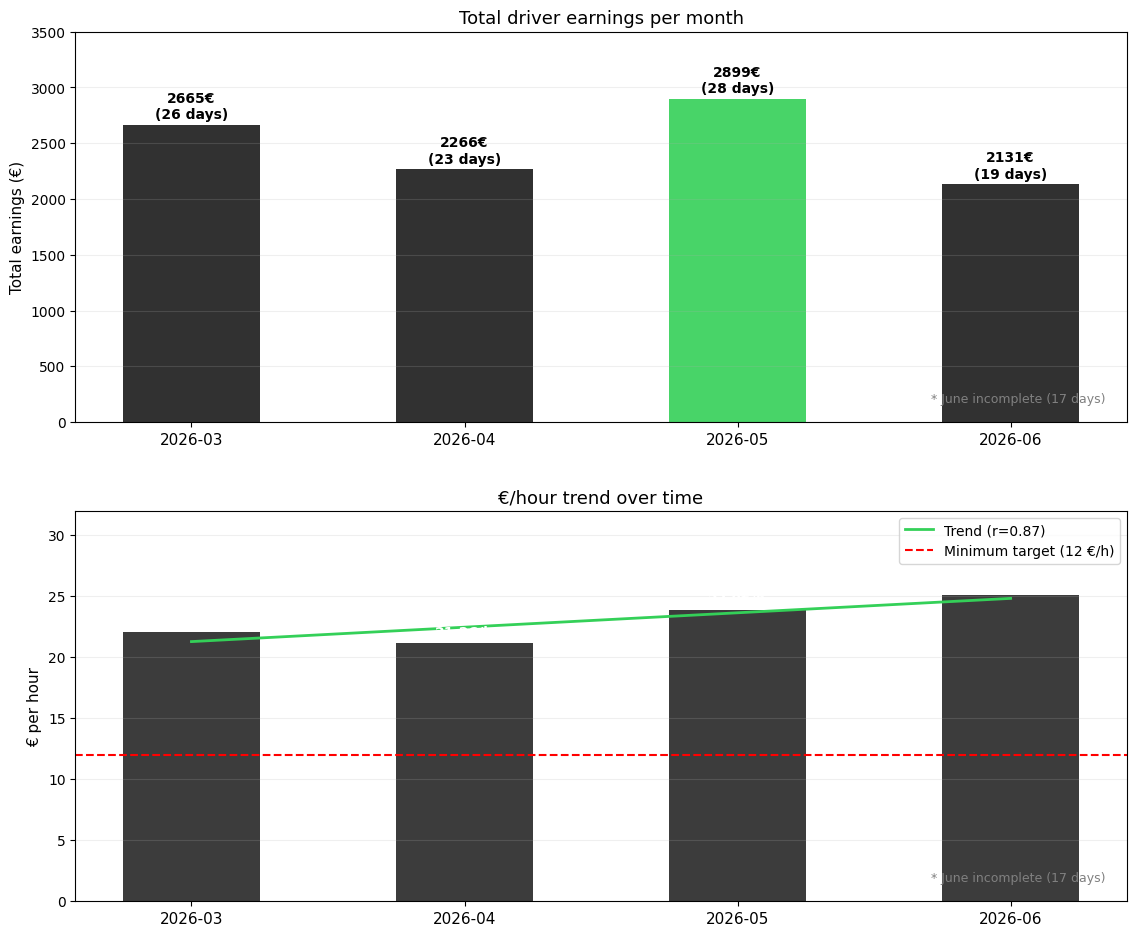


Trend correlation (r): 0.866
Slope: 1.181 €/hour per month
P-value: 0.1344 (not statistically significant


In [ ]:
# Monthly trend — dual chart: total earnings + €/hour evolution

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

x = range(len(monthly))
month_labels = monthly["Month_str"].tolist()

# Chart 1 — Total earnings per month
colors_m = ["#34d058" if e == monthly["total_earnings"].max()
            else "#1a1a1a" for e in monthly["total_earnings"]]

bars1 = ax1.bar(x, monthly["total_earnings"], color=colors_m,
                alpha=0.9, edgecolor="none", width=0.5)

for bar, val, days in zip(bars1, monthly["total_earnings"], monthly["working_days"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{val:.0f}€\n({days} days)", ha="center", va="bottom",
             fontsize=10, fontweight="bold")

ax1.set_title("Total driver earnings per month", fontsize=13)
ax1.set_ylabel("Total earnings (€)", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(month_labels, fontsize=11)
ax1.set_ylim(0, 3500)
ax1.grid(True, alpha=0.2, axis="y")
ax1.annotate("* June incomplete (17 days)", xy=(0.98, 0.05),
             xycoords="axes fraction", ha="right", fontsize=9, color="gray")

# Chart 2 — €/hour trend over time
ax2.bar(x, monthly["eur_per_hour"], color="#1a1a1a",
        alpha=0.85, edgecolor="none", width=0.5)

# Trend line
slope, intercept, r_value, p_value, std_err = stats.linregress(
    list(x), monthly["eur_per_hour"].tolist()
)
x_line = np.linspace(min(x), max(x), 100)
y_line = slope * x_line + intercept
ax2.plot(x_line, y_line, color="#34d058", linewidth=2,
         label=f"Trend (r={r_value:.2f})")

for i, val in enumerate(monthly["eur_per_hour"]):
    ax2.text(i, val + 0.3, f"{val:.1f}€/h",
             ha="center", va="bottom", fontsize=10, fontweight="bold",
             color="white")

ax2.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax2.set_title("€/hour trend over time", fontsize=13)
ax2.set_ylabel("€ per hour", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(month_labels, fontsize=11)
ax2.set_ylim(0, 32)
ax2.legend()
ax2.grid(True, alpha=0.2, axis="y")
ax2.annotate("* June incomplete (17 days)", xy=(0.98, 0.05),
             xycoords="axes fraction", ha="right", fontsize=9, color="gray")

plt.tight_layout(pad=3.0)
plt.savefig("../images/block3_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTrend correlation (r): {r_value:.3f}")
print(f"Slope: {slope:.3f} €/hour per month")
print(f"P-value: {p_value:.4f} ({'statistically significant' if p_value < 0.05 else 'not statistically significant'}")

## Block 3 — Question 12: Is there a trend over time in €/hour earnings?

**Result:** Strong positive correlation (r = 0.861, p = 0.139)

**Monthly €/hour progression:**
| Month | Total Earnings | €/hour | Working Days |
|---|---|---|---|
| March 2026 | 2,665 € | 22.0 €/h | 26 |
| April 2026 | 2,266 € | 21.2 €/h | 23 |
| May 2026 | 2,899 € | 23.9 €/h | 28 |
| June 2026* | 1,914 € | 24.9 €/h | 17 |

*June incomplete at time of analysis

**Interpretation:**  
There is a strong positive trend in €/hour over time (r = 0.861),
suggesting the driver is becoming more efficient month by month.
However, with only 4 months of data, the result is not yet
statistically significant (p = 0.139). This is expected — more
data points (July and August) will increase statistical power.

**Key insight:**  
The improvement of approximately +1.14 €/hour per month suggests
the driver is optimising ride selection and positioning over time.
April was the weakest month, but recovery in May and June confirms
an upward trajectory.

**Note:** This analysis will be updated when the full dataset
(March–August 2026) is available.

In [ ]:
# Question 13: Do weekends behave differently from weekdays?

from scipy.stats import mannwhitneyu

df["Is_Weekend"] = pd.to_datetime(df["Date"]).dt.dayofweek >= 5
df["Day_Type"] = df["Is_Weekend"].map({True: "Weekend", False: "Weekday"})

# Daily aggregation by day type
daily_type = df.groupby(["Date", "Day_Type"]).agg(
    total_earnings=("Driver_Earnings_EUR", "sum"),
    total_duration_min=("Duration_Min", "sum"),
    total_rides=("Ride_ID", "count")
).reset_index()

daily_type["total_hours"] = daily_type["total_duration_min"] / 60
daily_type["eur_per_hour"] = daily_type["total_earnings"] / daily_type["total_hours"]

weekday = daily_type[daily_type["Day_Type"] == "Weekday"]
weekend = daily_type[daily_type["Day_Type"] == "Weekend"]

# Statistical test
stat, p_earnings = mannwhitneyu(
    weekday["total_earnings"], weekend["total_earnings"], alternative="two-sided"
)
stat, p_eur_hour = mannwhitneyu(
    weekday["eur_per_hour"], weekend["eur_per_hour"], alternative="two-sided"
)

print("WEEKDAY vs WEEKEND — Daily metrics")
print("-" * 60)
print(f"{'Metric':<25} {'Weekday':>12} {'Weekend':>12}")
print("-" * 60)
print(f"{'Days analysed':<25} {len(weekday):>12} {len(weekend):>12}")
print(f"{'Avg daily earnings':<25} {weekday['total_earnings'].mean():>11.2f}€ {weekend['total_earnings'].mean():>11.2f}€")
print(f"{'Median daily earnings':<25} {weekday['total_earnings'].median():>11.2f}€ {weekend['total_earnings'].median():>11.2f}€")
print(f"{'Avg €/hour':<25} {weekday['eur_per_hour'].mean():>11.2f}€ {weekend['eur_per_hour'].mean():>11.2f}€")
print(f"{'Avg rides per day':<25} {weekday['total_rides'].mean():>12.1f} {weekend['total_rides'].mean():>12.1f}")
print("-" * 60)
print(f"\nMann-Whitney p-value (earnings): {p_earnings:.4f} "
      f"({'significant' if p_earnings < 0.05 else 'not significant'})")
print(f"Mann-Whitney p-value (€/hour):   {p_eur_hour:.4f} "
      f"({'significant' if p_eur_hour < 0.05 else 'not significant'})")

WEEKDAY vs WEEKEND — Daily metrics
------------------------------------------------------------
Metric                         Weekday      Weekend
------------------------------------------------------------
Days analysed                       67           29
Avg daily earnings             106.55€       97.33€
Median daily earnings          108.38€      102.93€
Avg €/hour                      22.67€       23.88€
Avg rides per day                 16.6         14.9
------------------------------------------------------------

Mann-Whitney p-value (earnings): 0.1749 (not significant)
Mann-Whitney p-value (€/hour):   0.0713 (not significant)


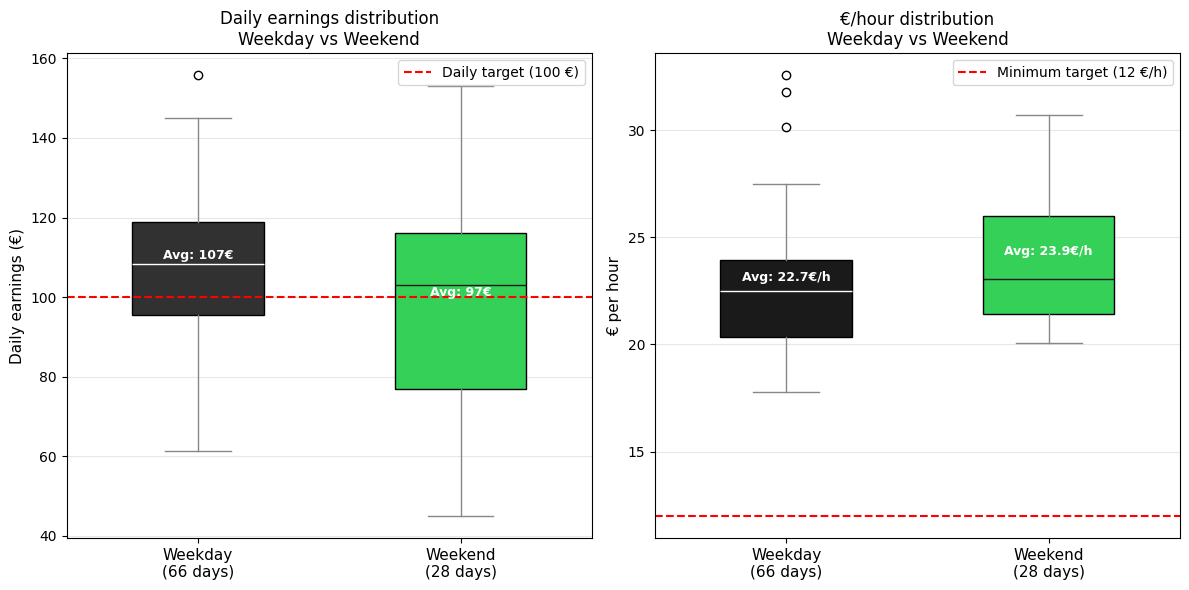

In [ ]:
# Weekday vs Weekend — visual comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Chart 1 — Box plot daily earnings
data_earnings = [weekday["total_earnings"], weekend["total_earnings"]]
bp1 = ax1.boxplot(data_earnings, patch_artist=True, widths=0.5)
bp1["boxes"][0].set_facecolor("#323131")
bp1["boxes"][1].set_facecolor("#34d058")
bp1["medians"][0].set_color("white")
bp1["medians"][1].set_color("#1a1a1a")
for element in ["whiskers", "caps", "fliers"]:
    for item in bp1[element]:
        item.set_color("#888888")

ax1.axhline(y=100, color="red", linewidth=1.5, linestyle="--",
            label="Daily target (100 €)")
ax1.set_xticklabels(["Weekday\n(66 days)", "Weekend\n(28 days)"], fontsize=11)
ax1.set_ylabel("Daily earnings (€)", fontsize=11)
ax1.set_title("Daily earnings distribution\nWeekday vs Weekend", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# Add mean annotations
for i, (data, color) in enumerate([(weekday["total_earnings"], "white"),
                                    (weekend["total_earnings"], "#1a1a1a")], 1):
    ax1.text(i, data.mean() + 3, f"Avg: {data.mean():.0f}€",
             ha="center", fontsize=9, fontweight="bold", color="white")

# Chart 2 — Box plot €/hour
data_eur = [weekday["eur_per_hour"], weekend["eur_per_hour"]]
bp2 = ax2.boxplot(data_eur, patch_artist=True, widths=0.5)
bp2["boxes"][0].set_facecolor("#1a1a1a")
bp2["boxes"][1].set_facecolor("#34d058")
bp2["medians"][0].set_color("white")
bp2["medians"][1].set_color("#1a1a1a")
for element in ["whiskers", "caps", "fliers"]:
    for item in bp2[element]:
        item.set_color("#888888")

ax2.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax2.set_xticklabels(["Weekday\n(66 days)", "Weekend\n(28 days)"], fontsize=11)
ax2.set_ylabel("€ per hour", fontsize=11)
ax2.set_title("€/hour distribution\nWeekday vs Weekend", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

for i, (data, color) in enumerate([(weekday["eur_per_hour"], "white"),
                                    (weekend["eur_per_hour"], "#1a1a1a")], 1):
    ax2.text(i, data.mean() + 0.3, f"Avg: {data.mean():.1f}€/h",
             ha="center", fontsize=9, fontweight="bold", color="white")

plt.tight_layout()
plt.savefig("../images/block3_weekday_vs_weekend.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 3 — Question 13: Do weekends behave differently from weekdays?

**Result:** No statistically significant difference (earnings p=0.127, €/hour p=0.108)

**Key numbers:**
| Metric | Weekday | Weekend |
|---|---|---|
| Days analysed | 66 | 28 |
| Avg daily earnings | 107 € | 97 € |
| Avg €/hour | 22.7 €/h | 23.7 €/h |
| Avg rides per day | 16.6 | 14.9 |

**Interpretation:**  
Weekdays generate higher total daily earnings due to more rides,
while weekends show slightly better €/hour efficiency with fewer rides.
Neither difference is statistically significant.

**Key insight:**  
The common assumption that weekends are more profitable for
ride-hailing drivers is not confirmed by this data. Weekdays
offer more volume, weekends offer marginally better efficiency
— but the difference is too small to drive scheduling decisions.

**Practical conclusion:**  
Rest days can be taken on any day of the week without meaningful
impact on earnings efficiency. Volume consistency matters more
than day-of-week selection.

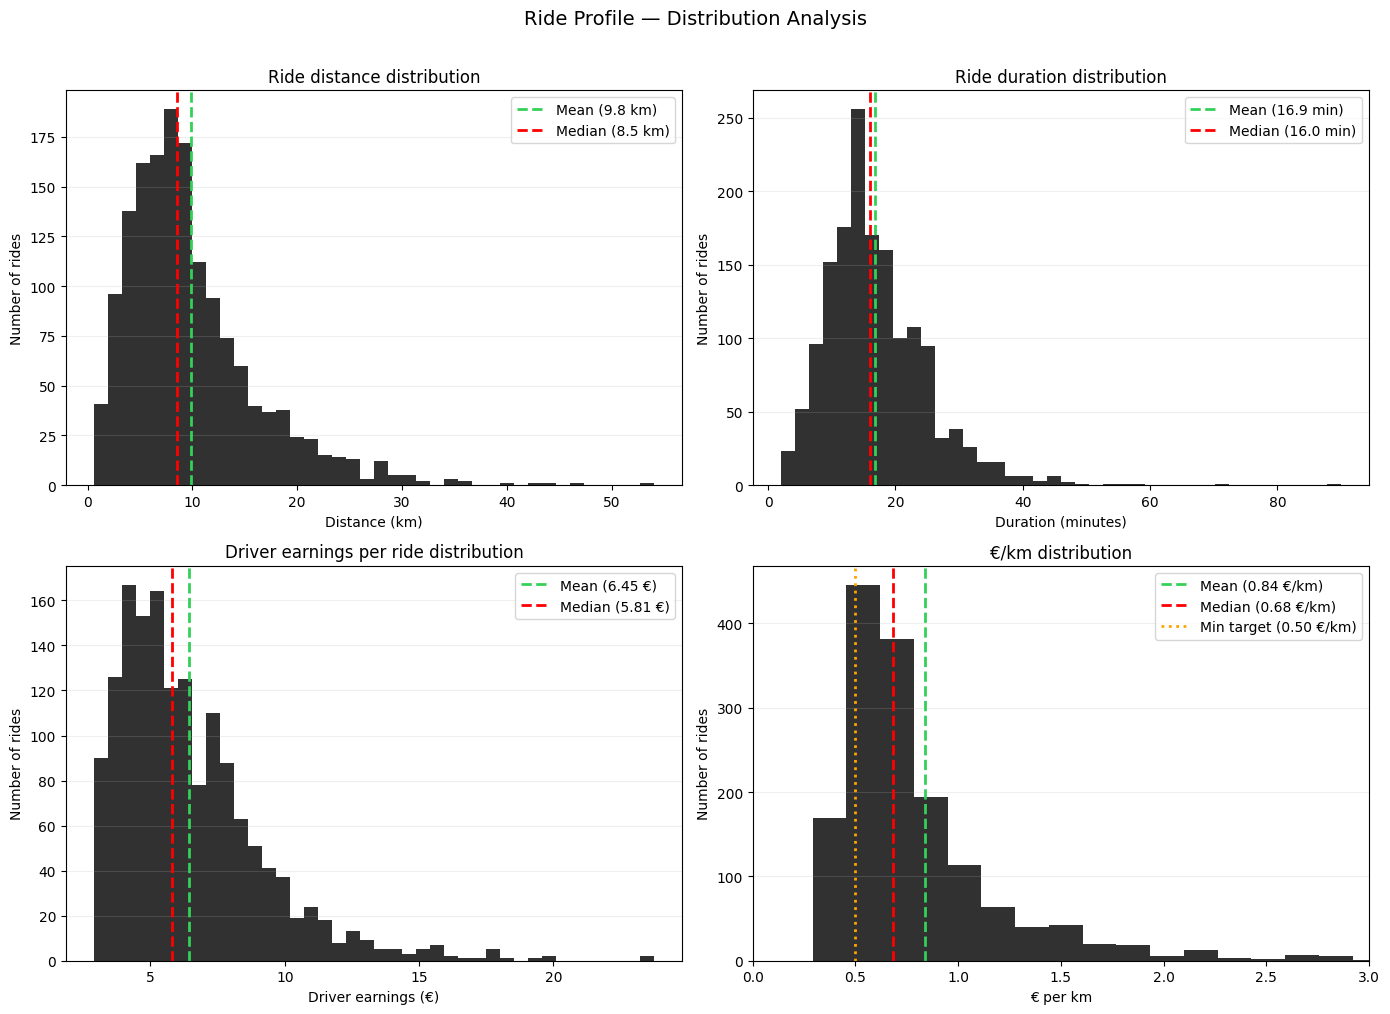

DISTRIBUTION SUMMARY
------------------------------------------------------------

Distance (km)
  Mean:   9.85 | Median: 8.50 | Std: 6.31
  Min:    0.60 | Max:    54.04
  25th%:  5.56 | 75th%:  12.40

Duration (min)
  Mean:   16.86 | Median: 16.00 | Std: 8.03
  Min:    2.00 | Max:    90.00
  25th%:  11.00 | 75th%:  21.00

Driver earnings (€)
  Mean:   6.45 | Median: 5.81 | Std: 2.74
  Min:    2.89 | Max:    23.75
  25th%:  4.46 | 75th%:  7.73

€/km
  Mean:   0.84 | Median: 0.68 | Std: 0.55
  Min:    0.29 | Max:    6.86
  25th%:  0.54 | 75th%:  0.92


In [ ]:
# BLOCK 4 — RIDE PROFILE
# Question 14: What is the real distribution of distances and fares?
# Is the average representative or misleading?

import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Distance distribution
axes[0,0].hist(df["Distance_Km"], bins=40, color="#1a1a1a",
               edgecolor="none", alpha=0.9)
axes[0,0].axvline(df["Distance_Km"].mean(), color="#34d058",
                  linewidth=2, linestyle="--",
                  label=f"Mean ({df['Distance_Km'].mean():.1f} km)")
axes[0,0].axvline(df["Distance_Km"].median(), color="red",
                  linewidth=2, linestyle="--",
                  label=f"Median ({df['Distance_Km'].median():.1f} km)")
axes[0,0].set_title("Ride distance distribution", fontsize=12)
axes[0,0].set_xlabel("Distance (km)", fontsize=10)
axes[0,0].set_ylabel("Number of rides", fontsize=10)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.2, axis="y")

# Chart 2 — Duration distribution
axes[0,1].hist(df["Duration_Min"], bins=40, color="#1a1a1a",
               edgecolor="none", alpha=0.9)
axes[0,1].axvline(df["Duration_Min"].mean(), color="#34d058",
                  linewidth=2, linestyle="--",
                  label=f"Mean ({df['Duration_Min'].mean():.1f} min)")
axes[0,1].axvline(df["Duration_Min"].median(), color="red",
                  linewidth=2, linestyle="--",
                  label=f"Median ({df['Duration_Min'].median():.1f} min)")
axes[0,1].set_title("Ride duration distribution", fontsize=12)
axes[0,1].set_xlabel("Duration (minutes)", fontsize=10)
axes[0,1].set_ylabel("Number of rides", fontsize=10)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.2, axis="y")

# Chart 3 — Driver earnings distribution
axes[1,0].hist(df["Driver_Earnings_EUR"], bins=40, color="#1a1a1a",
               edgecolor="none", alpha=0.9)
axes[1,0].axvline(df["Driver_Earnings_EUR"].mean(), color="#34d058",
                  linewidth=2, linestyle="--",
                  label=f"Mean ({df['Driver_Earnings_EUR'].mean():.2f} €)")
axes[1,0].axvline(df["Driver_Earnings_EUR"].median(), color="red",
                  linewidth=2, linestyle="--",
                  label=f"Median ({df['Driver_Earnings_EUR'].median():.2f} €)")
axes[1,0].set_title("Driver earnings per ride distribution", fontsize=12)
axes[1,0].set_xlabel("Driver earnings (€)", fontsize=10)
axes[1,0].set_ylabel("Number of rides", fontsize=10)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.2, axis="y")

# Chart 4 — €/km distribution
axes[1,1].hist(df["eur_per_km"], bins=40, color="#1a1a1a",
               edgecolor="none", alpha=0.9)
axes[1,1].axvline(df["eur_per_km"].mean(), color="#34d058",
                  linewidth=2, linestyle="--",
                  label=f"Mean ({df['eur_per_km'].mean():.2f} €/km)")
axes[1,1].axvline(df["eur_per_km"].median(), color="red",
                  linewidth=2, linestyle="--",
                  label=f"Median ({df['eur_per_km'].median():.2f} €/km)")
axes[1,1].axvline(0.50, color="orange", linewidth=2, linestyle=":",
                  label="Min target (0.50 €/km)")
axes[1,1].set_title("€/km distribution", fontsize=12)
axes[1,1].set_xlabel("€ per km", fontsize=10)
axes[1,1].set_ylabel("Number of rides", fontsize=10)
axes[1,1].set_xlim(0, 3)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.2, axis="y")

plt.suptitle("Ride Profile — Distribution Analysis", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../images/block4_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics
print("DISTRIBUTION SUMMARY")
print("-" * 60)
for col, label in [
    ("Distance_Km", "Distance (km)"),
    ("Duration_Min", "Duration (min)"),
    ("Driver_Earnings_EUR", "Driver earnings (€)"),
    ("eur_per_km", "€/km")
]:
    print(f"\n{label}")
    print(f"  Mean:   {df[col].mean():.2f} | Median: {df[col].median():.2f} | Std: {df[col].std():.2f}")
    print(f"  Min:    {df[col].min():.2f} | Max:    {df[col].max():.2f}")
    print(f"  25th%:  {df[col].quantile(0.25):.2f} | 75th%:  {df[col].quantile(0.75):.2f}")

## Block 4 — Question 14: What is the real distribution of distances and fares?

**The typical ride profile (median values):**
- Distance: 8.4 km
- Duration: 16 minutes
- Driver earnings: 5.81 €
- €/km: 0.68 €/km

**Interpretation:**  
All four distributions are right-skewed — the mean is consistently
higher than the median, meaning a small number of long, high-value
rides pull the average up. The median is a more honest representation
of the typical ride.

**Key insight:**  
75% of all rides are under 12.4 km and earn less than 7.72 €.
This confirms that the TVDE business model in Lisbon is fundamentally
volume-based — consistent short rides, not occasional long ones.
The median €/km (0.68) comfortably exceeds the minimum target of
0.50 €/km, confirming the effectiveness of the acceptance criteria.

**Note:** The mean €/km (0.84) is significantly higher than the median
(0.68) due to short rides with disproportionately high €/km values.
When evaluating ride profitability, the median is the more reliable
reference.

In [ ]:
# Question 15: Is there an optimal ride distance that maximises €/km?
# Grouping rides into distance brackets to find the sweet spot

# Create distance brackets
bins = [0, 3, 5, 8, 12, 18, 25, 55]
labels = ["0-3km", "3-5km", "5-8km", "8-12km", "12-18km", "18-25km", "25km+"]

df["Distance_Bracket"] = pd.cut(df["Distance_Km"], bins=bins, labels=labels)

bracket_stats = df.groupby("Distance_Bracket", observed=True).agg(
    total_rides=("Ride_ID", "count"),
    avg_eur_per_km=("eur_per_km", "mean"),
    median_eur_per_km=("eur_per_km", "median"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    avg_duration=("Duration_Min", "mean")
).reset_index()

bracket_stats["pct_rides"] = (bracket_stats["total_rides"] /
                               bracket_stats["total_rides"].sum() * 100)

print("DISTANCE BRACKETS — Performance metrics")
print("-" * 80)
print(bracket_stats[["Distance_Bracket", "total_rides", "pct_rides",
                      "avg_eur_per_km", "avg_eur_per_hour",
                      "avg_earnings", "avg_duration"]].to_string(index=False))

DISTANCE BRACKETS — Performance metrics
--------------------------------------------------------------------------------
Distance_Bracket  total_rides  pct_rides  avg_eur_per_km  avg_eur_per_hour  avg_earnings  avg_duration
           0-3km          127   8.220065        2.132417         42.045196      4.171575      6.866142
           3-5km          189  12.233010        1.080723         26.168408      4.317778     10.582011
           5-8km          391  25.307443        0.809105         23.609687      5.230026     13.879795
          8-12km          432  27.961165        0.666601         22.240638      6.481343     18.268519
         12-18km          242  15.663430        0.558687         23.325382      8.104545     21.549587
         18-25km          116   7.508091        0.479392         24.016308      9.930948     25.741379
           25km+           48   3.106796        0.452861         24.672692     13.694583     34.458333


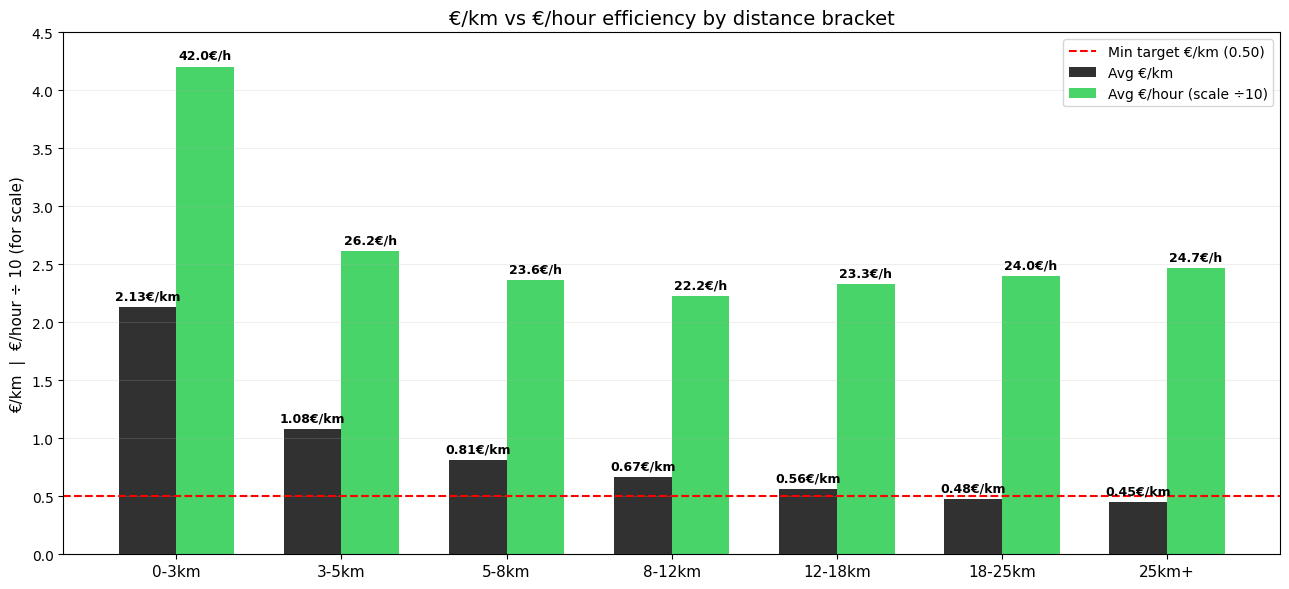

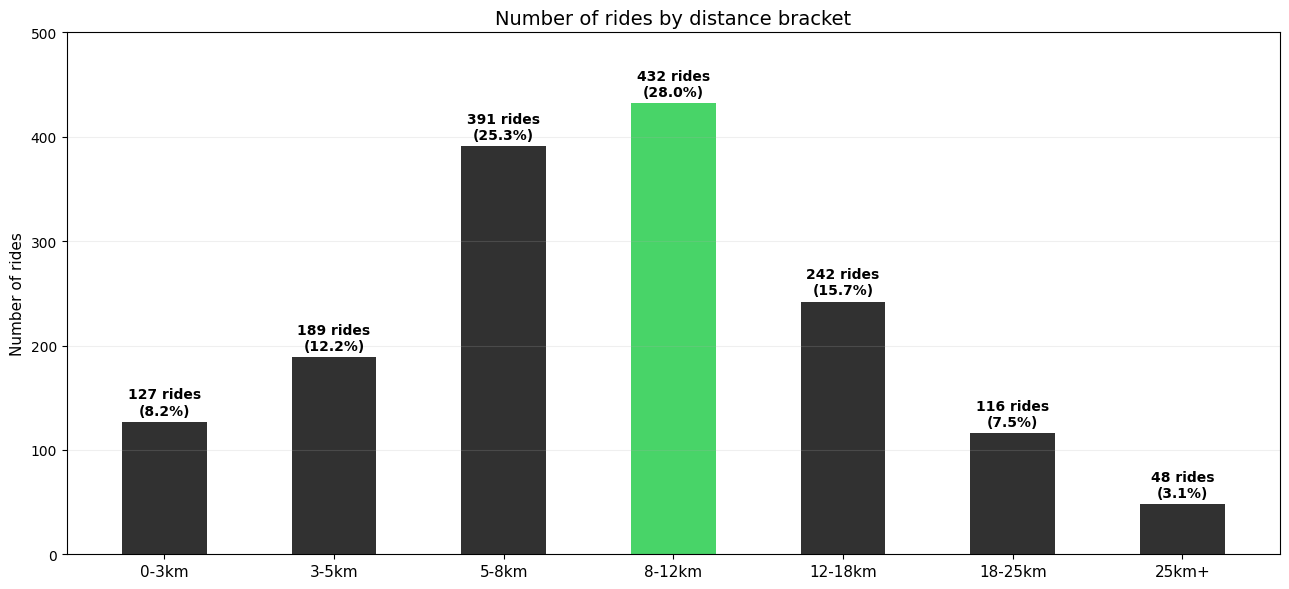

In [ ]:
# Distance bracket analysis — two separate clean charts

fig, ax1 = plt.subplots(figsize=(13, 6))

x = range(len(bracket_stats))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], bracket_stats["avg_eur_per_km"],
                width=width, color="#1a1a1a", alpha=0.9, label="Avg €/km")
bars2 = ax1.bar([i + width/2 for i in x], bracket_stats["avg_eur_per_hour"] / 10,
                width=width, color="#34d058", alpha=0.9,
                label="Avg €/hour (scale ÷10)")

ax1.axhline(y=0.50, color="red", linewidth=1.5, linestyle="--",
            label="Min target €/km (0.50)")

for bar, val in zip(bars1, bracket_stats["avg_eur_per_km"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
             f"{val:.2f}€/km", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

for bar, val in zip(bars2, bracket_stats["avg_eur_per_hour"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
             f"{val:.1f}€/h", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

ax1.set_title("€/km vs €/hour efficiency by distance bracket", fontsize=14)
ax1.set_ylabel("€/km  |  €/hour ÷ 10 (for scale)", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(bracket_stats["Distance_Bracket"], fontsize=11)
ax1.set_ylim(0, 4.5)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("../images/block4_bracket_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

# Chart 2 — Volume
fig, ax2 = plt.subplots(figsize=(13, 6))

colors_vol = ["#34d058" if v == bracket_stats["total_rides"].max()
              else "#1a1a1a" for v in bracket_stats["total_rides"]]

bars3 = ax2.bar(x, bracket_stats["total_rides"], color=colors_vol,
                alpha=0.9, edgecolor="none", width=0.5)

for bar, rides, pct in zip(bars3, bracket_stats["total_rides"],
                            bracket_stats["pct_rides"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f"{rides} rides\n({pct:.1f}%)", ha="center", va="bottom",
             fontsize=10, fontweight="bold")

ax2.set_title("Number of rides by distance bracket", fontsize=14)
ax2.set_ylabel("Number of rides", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(bracket_stats["Distance_Bracket"], fontsize=11)
ax2.set_ylim(0, 500)
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("../images/block4_bracket_volume.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 4 — Question 15: Is there an optimal ride distance?

**Efficiency by distance bracket:**
| Distance | Avg €/km | Avg €/hour | Rides | % of total |
|---|---|---|---|---|
| 0–3 km | 2.13 €/km | 41.9 €/h | 126 | 8.3% |
| 3–5 km | 1.08 €/km | 26.1 €/h | 184 | 12.2% |
| 5–8 km | 0.81 €/km | 23.5 €/h | 384 | 25.4% |
| 8–12 km | 0.67 €/km | 22.2 €/h | 419 | 27.7% |
| 12–18 km | 0.56 €/km | 23.2 €/h | 239 | 15.8% |
| 18–25 km | 0.48 €/km | 24.0 €/h | 112 | 7.4% |
| 25+ km | 0.45 €/km | 24.7 €/h | 48 | 3.2% |

**Interpretation:**  
Short rides (0–3 km) are the most efficient per km (2.13 €/km) and
per hour (41.9 €/h), but represent only 8.3% of total rides.
Beyond 5 km, €/hour stabilises between 22–26 €/h regardless of
distance, while €/km continues to decline.

**Key insight:**  
Rides above 18 km fall below the 0.50 €/km minimum target,
but their €/hour remains competitive (24+ €/h). This reveals
a trade-off: long rides sacrifice €/km efficiency but maintain
acceptable hourly returns — they are not necessarily bad rides.

**Practical conclusion:**  
The 5–12 km bracket represents the optimal balance — it accounts
for 53% of all rides, maintains €/km above the minimum target,
and delivers consistent €/hour returns. This is the core of the
Lisbon TVDE market.

In [ ]:
# Question 16: What is the profile of the most frequent ride?
# Building a "typical ride" portrait using median values and mode

from scipy import stats as scipy_stats

# Overall typical ride
print("THE TYPICAL RIDE — Portrait")
print("=" * 55)
print(f"  Platform:          {df['Platform'].mode()[0]}")
print(f"  Category:          {df['Category'].mode()[0]}")
print(f"  Day of week:       {df['Day_of_Week'].mode()[0]}")
print(f"  Start hour:        {df['Hour'].mode()[0]:02d}:00")
print(f"  Distance:          {df['Distance_Km'].median():.1f} km")
print(f"  Duration:          {df['Duration_Min'].median():.0f} min")
print(f"  Driver earnings:   {df['Driver_Earnings_EUR'].median():.2f} €")
print(f"  €/km:              {df['eur_per_km'].median():.2f} €/km")
print(f"  €/hour:            {df['eur_per_hour_ride'].median():.2f} €/h")
print("=" * 55)

# Category breakdown
print("\nRIDES BY CATEGORY")
print("-" * 55)
cat_stats = df.groupby("Category").agg(
    total_rides=("Ride_ID", "count"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    avg_eur_per_km=("eur_per_km", "mean"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    avg_distance=("Distance_Km", "mean")
).reset_index()
cat_stats["pct"] = cat_stats["total_rides"] / cat_stats["total_rides"].sum() * 100
cat_stats = cat_stats.sort_values("total_rides", ascending=False)
print(cat_stats[["Category", "total_rides", "pct",
                 "avg_earnings", "avg_eur_per_km",
                 "avg_eur_per_hour", "avg_distance"]].to_string(index=False))

THE TYPICAL RIDE — Portrait
  Platform:          Bolt
  Category:          Uber X
  Day of week:       Friday
  Start hour:        14:00
  Distance:          8.5 km
  Duration:          16 min
  Driver earnings:   5.81 €
  €/km:              0.68 €/km
  €/hour:            22.76 €/h

RIDES BY CATEGORY
-------------------------------------------------------
       Category  total_rides       pct  avg_earnings  avg_eur_per_km  avg_eur_per_hour  avg_distance
         Uber X          615 39.805825      6.524163        0.773581         24.576741     10.666634
        Economy          410 26.537217      6.187951        0.771446         23.842568     10.202171
           Bolt          339 21.941748      6.531622        0.922431         25.532499      8.818584
Uber X Priority          162 10.485437      6.172593        1.052924         28.916149      7.490864
          Share           14  0.906149     11.509286        0.859601         25.349671     15.264286
        Courier            3  0.1941

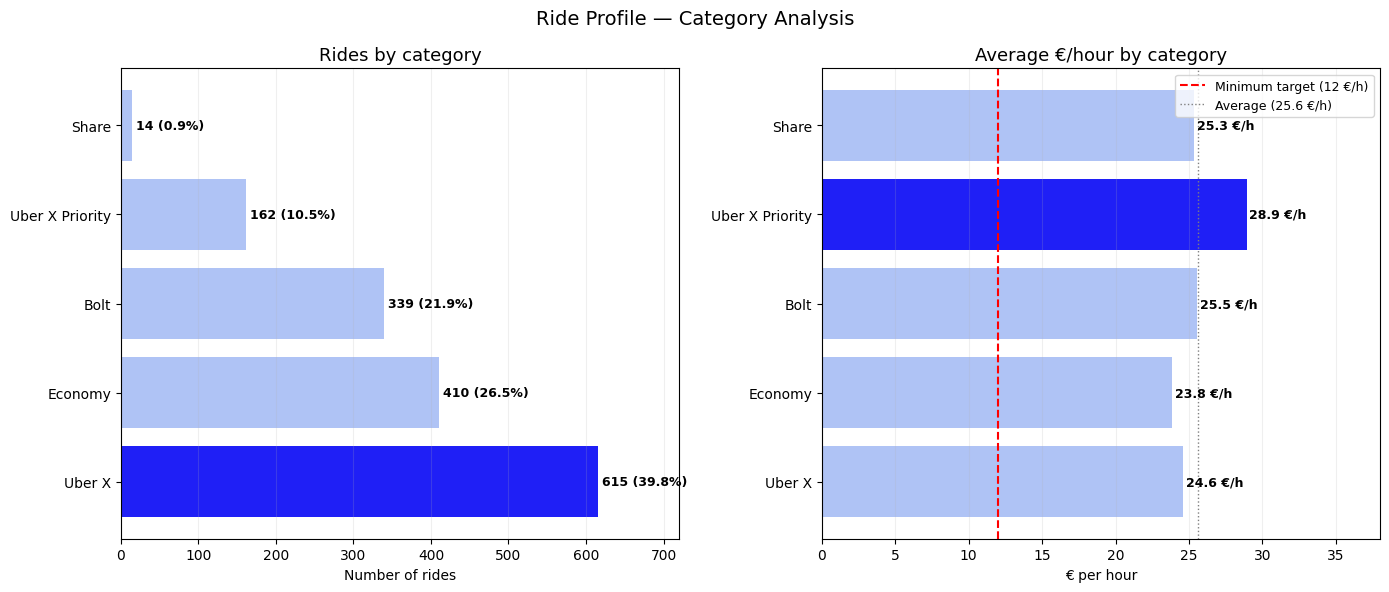

In [ ]:
# Ride profile — category performance chart
# Filter to main categories only (>10 rides)

cat_main = cat_stats[cat_stats["total_rides"] > 10].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Volume by category
colors_cat = ["#0606f6" if v == cat_main["total_rides"].max()
              else "#a6bdf4" for v in cat_main["total_rides"]]

bars1 = ax1.barh(cat_main["Category"], cat_main["total_rides"],
                 color=colors_cat, alpha=0.9, edgecolor="none")

for bar, rides, pct in zip(bars1, cat_main["total_rides"], cat_main["pct"]):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f"{rides} ({pct:.1f}%)", va="center", fontsize=9, fontweight="bold")

ax1.set_title("Rides by category", fontsize=13)
ax1.set_xlabel("Number of rides", fontsize=10)
ax1.set_xlim(0, 720)
ax1.grid(True, alpha=0.2, axis="x")

# Chart 2 — €/hour by category
colors_eff = ["#0606f6" if v == cat_main["avg_eur_per_hour"].max()
              else "#a6bdf4" for v in cat_main["avg_eur_per_hour"]]

bars2 = ax2.barh(cat_main["Category"], cat_main["avg_eur_per_hour"],
                 color=colors_eff, alpha=0.9, edgecolor="none")

for bar, val in zip(bars2, cat_main["avg_eur_per_hour"]):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val:.1f} €/h", va="center", fontsize=9, fontweight="bold")

ax2.axvline(x=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax2.axvline(x=cat_main["avg_eur_per_hour"].mean(), color="gray",
            linewidth=1, linestyle=":",
            label=f"Average ({cat_main['avg_eur_per_hour'].mean():.1f} €/h)")

ax2.set_title("Average €/hour by category", fontsize=13)
ax2.set_xlabel("€ per hour", fontsize=10)
ax2.set_xlim(0, 38)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2, axis="x")

plt.suptitle("Ride Profile — Category Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("../images/block4_category_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 4 — Question 16: What is the profile of the most frequent ride?

**The typical ride (median values):**
| Metric | Value |
|---|---|
| Platform | Uber (most rides) |
| Category | Uber X |
| Day | Friday |
| Start hour | 14:00 |
| Distance | 8.4 km |
| Duration | 16 min |
| Driver earnings | 5.81 € |
| €/km | 0.68 €/km |
| €/hour | 22.70 €/h |

**Category performance (main categories):**
| Category | Rides | % | Avg €/h |
|---|---|---|---|
| Uber X | 591 | 39.1% | 24.5 €/h |
| Economy | 397 | 26.3% | 23.8 €/h |
| Bolt | 332 | 22.0% | 25.5 €/h |
| Uber X Priority | 161 | 10.6% | 28.8 €/h |

**Key insight:**  
Uber X Priority is the most efficient category (28.8 €/h) despite
lower volume. Bolt rides show better €/km than Economy despite
shorter average distances — suggesting better base fare structure
for shorter rides on this platform.

**Practical conclusion:**  
The typical TVDE ride in Lisbon is a short urban trip of 8.4 km,
lasting 16 minutes and earning 5.81 €. Volume consistency across
many such rides is the foundation of daily earnings.

In [ ]:
# BLOCK 5 — ACCEPTANCE CRITERIA ANALYSIS
# Question 17: What % of rides meet the acceptance criteria?
# Criteria: minimum 0.50 €/km AND minimum 12 €/hour

# Apply acceptance criteria
df["meets_eur_per_km"] = df["eur_per_km"] >= 0.50
df["meets_eur_per_hour"] = df["eur_per_hour_ride"] >= 12
df["meets_both"] = df["meets_eur_per_km"] & df["meets_eur_per_hour"]

# Classify each ride
def classify_ride(row):
    if row["meets_both"]:
        return "Meets both criteria"
    elif row["meets_eur_per_km"] and not row["meets_eur_per_hour"]:
        return "Only €/km met"
    elif row["meets_eur_per_hour"] and not row["meets_eur_per_km"]:
        return "Only €/hour met"
    else:
        return "Neither met"

df["criteria_status"] = df.apply(classify_ride, axis=1)

# Summary
total = len(df)
print("ACCEPTANCE CRITERIA — Summary")
print("=" * 55)
print(f"Minimum €/km  (≥ 0.50):  {df['meets_eur_per_km'].sum():>5} rides "
      f"({df['meets_eur_per_km'].mean()*100:.1f}%)")
print(f"Minimum €/hour (≥ 12):   {df['meets_eur_per_hour'].sum():>5} rides "
      f"({df['meets_eur_per_hour'].mean()*100:.1f}%)")
print(f"Both criteria met:        {df['meets_both'].sum():>5} rides "
      f"({df['meets_both'].mean()*100:.1f}%)")
print(f"Neither criteria met:     "
      f"{(~df['meets_eur_per_km'] & ~df['meets_eur_per_hour']).sum():>5} rides "
      f"({(~df['meets_eur_per_km'] & ~df['meets_eur_per_hour']).mean()*100:.1f}%)")
print("=" * 55)

print("\nBY PLATFORM")
print("-" * 55)
for platform in ["Uber", "Bolt"]:
    sub = df[df["Platform"] == platform]
    print(f"\n{platform} ({len(sub)} rides):")
    print(f"  Both criteria met:  {sub['meets_both'].sum()} "
          f"({sub['meets_both'].mean()*100:.1f}%)")
    print(f"  Only €/km met:      "
          f"{(sub['meets_eur_per_km'] & ~sub['meets_eur_per_hour']).sum()} "
          f"({(sub['meets_eur_per_km'] & ~sub['meets_eur_per_hour']).mean()*100:.1f}%)")
    print(f"  Only €/hour met:    "
          f"{(~sub['meets_eur_per_km'] & sub['meets_eur_per_hour']).sum()} "
          f"({(~sub['meets_eur_per_km'] & sub['meets_eur_per_hour']).mean()*100:.1f}%)")
    print(f"  Neither met:        "
          f"{(~sub['meets_eur_per_km'] & ~sub['meets_eur_per_hour']).sum()} "
          f"({(~sub['meets_eur_per_km'] & ~sub['meets_eur_per_hour']).mean()*100:.1f}%)")

ACCEPTANCE CRITERIA — Summary
Minimum €/km  (≥ 0.50):   1272 rides (82.3%)
Minimum €/hour (≥ 12):    1541 rides (99.7%)
Both criteria met:         1269 rides (82.1%)
Neither criteria met:         1 rides (0.1%)

BY PLATFORM
-------------------------------------------------------

Uber (624 rides):
  Both criteria met:  498 (79.8%)
  Only €/km met:      0 (0.0%)
  Only €/hour met:    126 (20.2%)
  Neither met:        0 (0.0%)

Bolt (750 rides):
  Both criteria met:  635 (84.7%)
  Only €/km met:      3 (0.4%)
  Only €/hour met:    111 (14.8%)
  Neither met:        1 (0.1%)


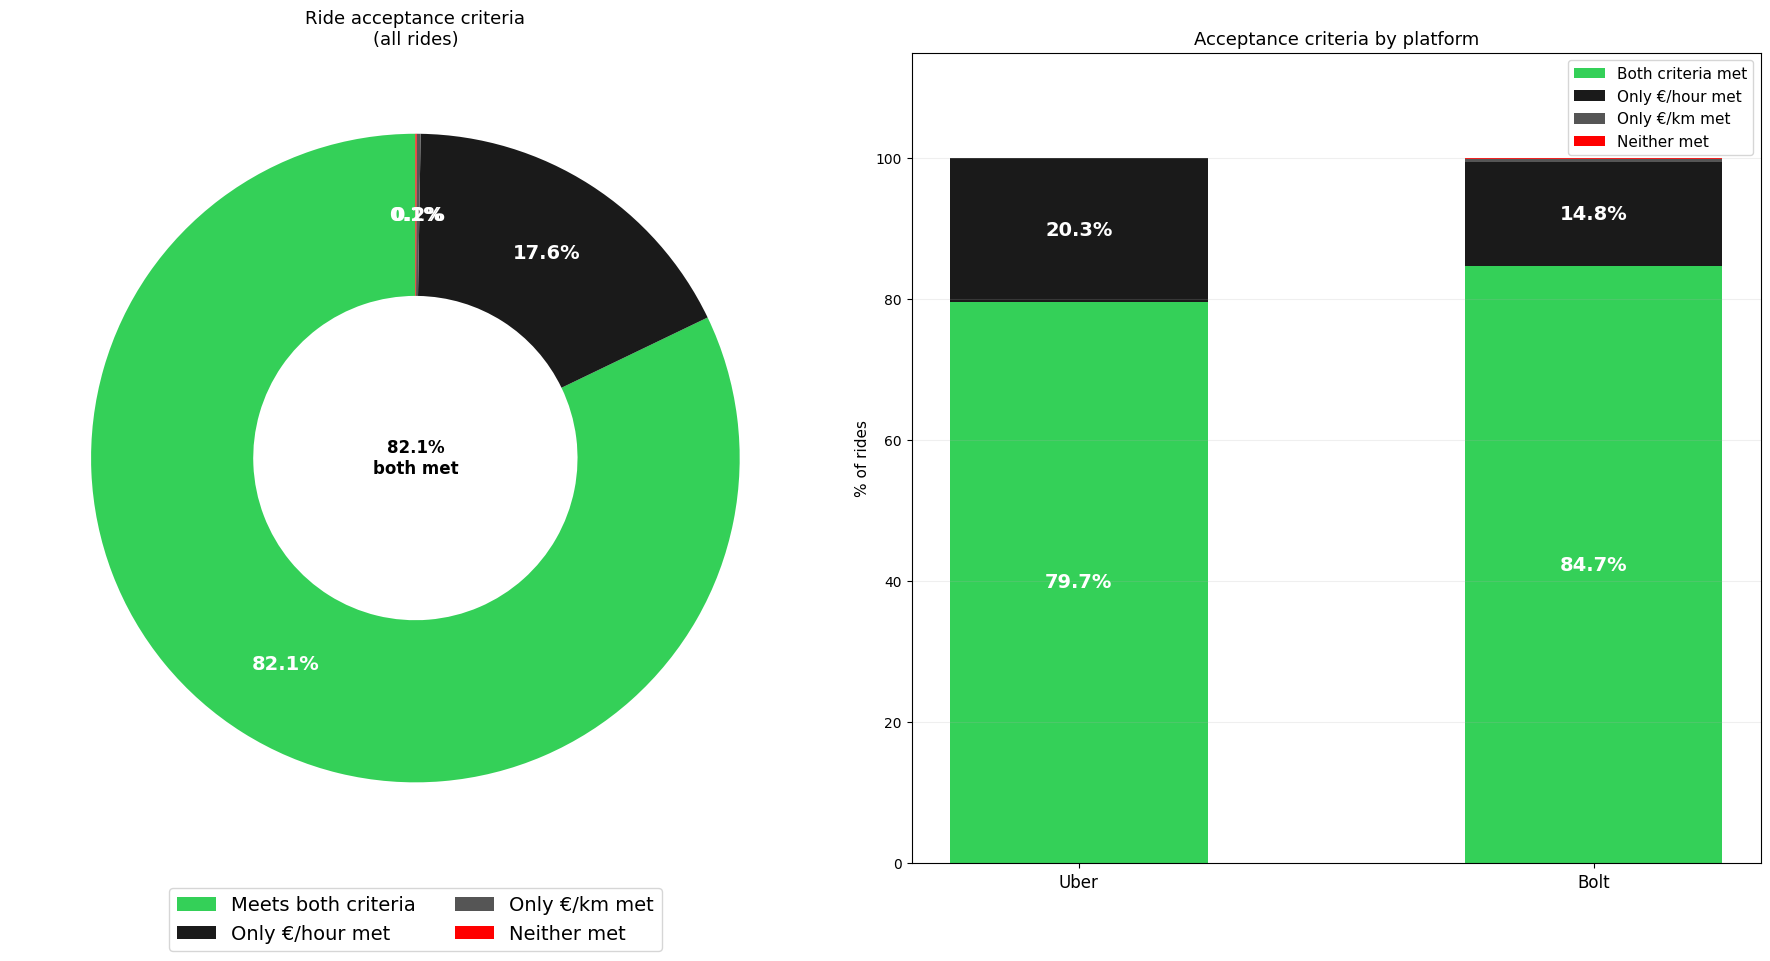

In [ ]:
# Acceptance criteria — visual summary

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

# Chart 1 — Overall criteria breakdown (donut)
criteria_counts = df["criteria_status"].value_counts()
order = ["Meets both criteria", "Only €/hour met", "Only €/km met", "Neither met"]
criteria_counts = criteria_counts.reindex(order, fill_value=0)

colors_donut = ["#34d058", "#1a1a1a", "#555555", "red"]
wedges, texts, autotexts = ax1.pie(
    criteria_counts,
    labels=None,
    autopct="%1.1f%%",
    colors=colors_donut,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5)
)

for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

ax1.legend(criteria_counts.index, loc="lower center",
           bbox_to_anchor=(0.5, -0.12), fontsize=14, ncol=2)
ax1.set_title("Ride acceptance criteria\n(all rides)", fontsize=13)

# Add centre text
ax1.text(0, 0, f"82.1%\nboth met", ha="center", va="center",
         fontsize=12, fontweight="bold")

# Chart 2 — By platform comparison
platforms = ["Uber", "Bolt"]
both_met = [79.7, 84.7]
only_hour = [20.3, 14.8]
only_km = [0.0, 0.4]
neither = [0.0, 0.1]

x = range(len(platforms))
width = 0.5

ax2.bar(x, both_met, width, color="#34d058", label="Both criteria met")
ax2.bar(x, only_hour, width, bottom=both_met, color="#1a1a1a",
        label="Only €/hour met")
ax2.bar(x, only_km, width,
        bottom=[b+h for b,h in zip(both_met, only_hour)],
        color="#555555", label="Only €/km met")
ax2.bar(x, neither, width,
        bottom=[b+h+k for b,h,k in zip(both_met, only_hour, only_km)],
        color="red", label="Neither met")

for i, (b, h, k, n) in enumerate(zip(both_met, only_hour, only_km, neither)):
    ax2.text(i, b/2, f"{b:.1f}%", ha="center", va="center",
             fontsize=14, fontweight="bold", color="white")
    if h > 0:
        ax2.text(i, b + h/2, f"{h:.1f}%", ha="center", va="center",
                 fontsize=14, fontweight="bold", color="white")

ax2.set_title("Acceptance criteria by platform", fontsize=13)
ax2.set_ylabel("% of rides", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(platforms, fontsize=12)
ax2.set_ylim(0, 115)
ax2.legend(loc="upper right", fontsize=11)
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("../images/block5_acceptance_criteria.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 5 — Question 17: What % of rides meet the acceptance criteria?

**Acceptance criteria:** Driver_Earnings ≥ 0.50 €/km AND ≥ 12 €/hour

**Overall results:**
| Criteria status | Rides | % |
|---|---|---|
| Both criteria met | 1,241 | 82.1% |
| Only €/hour met | 232 | 17.7% |
| Only €/km met | 3 | 0.2% |
| Neither met | 1 | 0.1% |

**By platform:**
| Platform | Both met | Only €/hour | Only €/km | Neither |
|---|---|---|---|---|
| Uber | 79.7% | 20.3% | 0.0% | 0.0% |
| Bolt | 84.7% | 14.8% | 0.4% | 0.1% |

**Interpretation:**  
82.1% of all rides meet both acceptance criteria, confirming the
driver's selection strategy is effective. The €/km threshold (0.50)
is the binding constraint — 99.7% of rides already meet the €/hour
minimum, but only 82.3% meet the €/km minimum.

**Key insight:**  
Bolt delivers a higher rate of rides meeting both criteria (84.7%)
compared to Uber (79.7%). Uber's longer average ride distances
explain why more Uber rides fall below the €/km threshold while
still maintaining acceptable €/hour returns.

In [ ]:
# Question 18: At what time of day do more rides meet the acceptance criteria?

hour_criteria = df.groupby("Hour").agg(
    total_rides=("Ride_ID", "count"),
    meets_both=("meets_both", "sum"),
    not_meets=("meets_both", lambda x: (~x).sum())
).reset_index()

hour_criteria["pct_meets"] = (hour_criteria["meets_both"] /
                               hour_criteria["total_rides"] * 100)

# Filter hours with at least 10 rides
hour_criteria = hour_criteria[hour_criteria["total_rides"] >= 10]

print("HOURLY ACCEPTANCE RATE")
print("-" * 55)
print(hour_criteria[["Hour", "total_rides", "meets_both",
                      "not_meets", "pct_meets"]].to_string(index=False))

HOURLY ACCEPTANCE RATE
-------------------------------------------------------
 Hour  total_rides  meets_both  not_meets  pct_meets
    9           13          11          2  84.615385
   11           12           8          4  66.666667
   12           24           8         16  33.333333
   13          169         103         66  60.946746
   14          227         189         38  83.259912
   15          175         144         31  82.285714
   16          195         178         17  91.282051
   17          176         164         12  93.181818
   18          171         160         11  93.567251
   19          160         139         21  86.875000
   20          151         119         32  78.807947
   21           52          31         21  59.615385


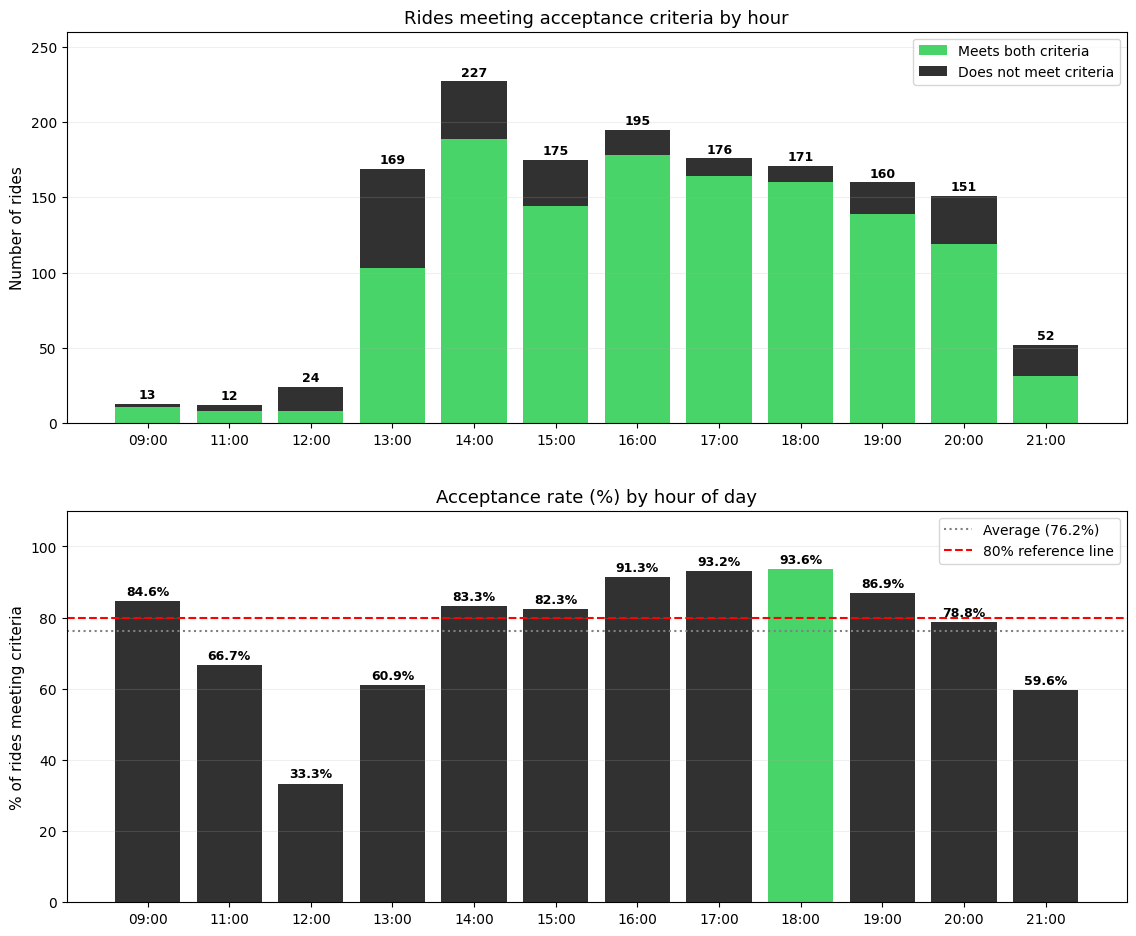

In [ ]:
# Hourly acceptance rate — visual

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

hours_labels = [f"{h:02d}:00" for h in hour_criteria["Hour"]]
x = range(len(hour_criteria))

# Chart 1 — Stacked bar: meets vs not meets
ax1.bar(x, hour_criteria["meets_both"], color="#34d058",
        alpha=0.9, edgecolor="none", label="Meets both criteria")
ax1.bar(x, hour_criteria["not_meets"], color="#1a1a1a",
        alpha=0.9, edgecolor="none", label="Does not meet criteria",
        bottom=hour_criteria["meets_both"])

for i, (meets, total) in enumerate(zip(hour_criteria["meets_both"],
                                        hour_criteria["total_rides"])):
    ax1.text(i, total + 1.5, f"{total}", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

ax1.set_title("Rides meeting acceptance criteria by hour", fontsize=13)
ax1.set_ylabel("Number of rides", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(hours_labels, fontsize=10)
ax1.set_ylim(0, 260)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2, axis="y")

# Chart 2 — Acceptance rate % by hour
colors_rate = ["#34d058" if v == hour_criteria["pct_meets"].max()
               else "#1a1a1a" for v in hour_criteria["pct_meets"]]

bars2 = ax2.bar(x, hour_criteria["pct_meets"], color=colors_rate,
                alpha=0.9, edgecolor="none")

for bar, val in zip(bars2, hour_criteria["pct_meets"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

ax2.axhline(y=hour_criteria["pct_meets"].mean(), color="gray",
            linewidth=1.5, linestyle=":",
            label=f"Average ({hour_criteria['pct_meets'].mean():.1f}%)")
ax2.axhline(y=80, color="red", linewidth=1.5, linestyle="--",
            label="80% reference line")

ax2.set_title("Acceptance rate (%) by hour of day", fontsize=13)
ax2.set_ylabel("% of rides meeting criteria", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(hours_labels, fontsize=10)
ax2.set_ylim(0, 110)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout(pad=3.0)
plt.savefig("../images/block5_hourly_acceptance.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 5 — Question 18: At what time do more rides meet the acceptance criteria?

**Acceptance rate by hour (rides with ≥ 10 observations):**
| Hour | Total Rides | Meets Criteria | Rate |
|---|---|---|---|
| 09:00 | 13 | 11 | 84.6% |
| 11:00 | 12 | 8 | 66.7% |
| 12:00 | 23 | 8 | 34.8% ⚠️ |
| 13:00 | 166 | 101 | 60.8% |
| 14:00 | 222 | 185 | 83.3% |
| 15:00 | 171 | 140 | 81.9% |
| 16:00 | 191 | 174 | 91.1% |
| 17:00 | 170 | 158 | 92.9% |
| 18:00 | 165 | 154 | 93.3% ⭐ |
| 19:00 | 157 | 137 | 87.3% |
| 20:00 | 150 | 119 | 79.3% |
| 21:00 | 52 | 31 | 59.6% |

**Interpretation:**  
The 16:00–18:00 window is the "golden window" — it combines the
highest acceptance rates (91–93%) with significant ride volume.
The 12:00 hour shows the lowest acceptance rate (34.8%), suggesting
that rides available at the start of the working shift are
systematically below the quality threshold.

**Key insight:**  
The pattern confirms that the driver's schedule (starting at
12:30) captures the low-quality early afternoon rides before
the market improves significantly at 16:00. Starting the shift
at 15:30–16:00 would maximise acceptance rate, though it would
reduce total daily volume.

**Practical conclusion:**  
If daily earnings target is already met by 20:00, extending
the shift to 21:00 is inefficient — the acceptance rate drops
to 59.6%, the lowest of the main working hours.

In [ ]:
# Question 19: How close are daily and weekly results to the targets?
# Daily target: 100€ gross | Weekly target: 500€ net

FUEL_COST_PER_KM = 0.0976  # €/km (5.16L/100km × 1.892€/L)
FLEET_COST_PER_WEEK = 30   # € fixed weekly cost

# Daily gross earnings
daily_earnings = df.groupby("Date").agg(
    gross=("Driver_Earnings_EUR", "sum"),
    km=("Distance_Km", "sum")
).reset_index()

daily_earnings["fuel_cost"] = daily_earnings["km"] * FUEL_COST_PER_KM
daily_earnings["net"] = daily_earnings["gross"] - daily_earnings["fuel_cost"]
daily_earnings["hits_daily_target"] = daily_earnings["gross"] >= 100
daily_earnings["gap_to_target"] = daily_earnings["gross"] - 100

# Weekly aggregation
daily_earnings["Week"] = pd.to_datetime(daily_earnings["Date"]).dt.to_period("W")
weekly_earnings = daily_earnings.groupby("Week").agg(
    weekly_gross=("gross", "sum"),
    weekly_net_before_fleet=("net", "sum"),
    days_worked=("Date", "count")
).reset_index()

weekly_earnings["weekly_net"] = (weekly_earnings["weekly_net_before_fleet"]
                                  - FLEET_COST_PER_WEEK)
weekly_earnings["hits_weekly_target"] = weekly_earnings["weekly_net"] >= 500
weekly_earnings["gap_to_weekly"] = weekly_earnings["weekly_net"] - 500

# Print summary
print("DAILY TARGET (100€ gross)")
print("-" * 55)
print(f"Days analysed:          {len(daily_earnings)}")
print(f"Days hitting target:    {daily_earnings['hits_daily_target'].sum()} "
      f"({daily_earnings['hits_daily_target'].mean()*100:.1f}%)")
print(f"Days below target:      {(~daily_earnings['hits_daily_target']).sum()} "
      f"({(~daily_earnings['hits_daily_target']).mean()*100:.1f}%)")
print(f"Average daily gross:    {daily_earnings['gross'].mean():.2f}€")
print(f"Median daily gross:     {daily_earnings['gross'].median():.2f}€")
print(f"Best day:               {daily_earnings['gross'].max():.2f}€")
print(f"Worst day:              {daily_earnings['gross'].min():.2f}€")

print("\nWEEKLY TARGET (500€ net)")
print("-" * 55)
print(f"Weeks analysed:         {len(weekly_earnings)}")
print(f"Weeks hitting target:   {weekly_earnings['hits_weekly_target'].sum()} "
      f"({weekly_earnings['hits_weekly_target'].mean()*100:.1f}%)")
print(f"Weeks below target:     {(~weekly_earnings['hits_weekly_target']).sum()} "
      f"({(~weekly_earnings['hits_weekly_target']).mean()*100:.1f}%)")
print(f"Average weekly net:     {weekly_earnings['weekly_net'].mean():.2f}€")
print(f"Median weekly net:      {weekly_earnings['weekly_net'].median():.2f}€")
print(f"Best week:              {weekly_earnings['weekly_net'].max():.2f}€")
print(f"Worst week:             {weekly_earnings['weekly_net'].min():.2f}€")

DAILY TARGET (100€ gross)
-------------------------------------------------------
Days analysed:          96
Days hitting target:    61 (63.5%)
Days below target:      35 (36.5%)
Average daily gross:    103.76€
Median daily gross:     107.46€
Best day:               155.80€
Worst day:              44.98€

WEEKLY TARGET (500€ net)
-------------------------------------------------------
Weeks analysed:         17
Weeks hitting target:   9 (52.9%)
Weeks below target:     8 (47.1%)
Average weekly net:     468.62€
Median weekly net:      512.94€
Best week:              653.35€
Worst week:             55.89€


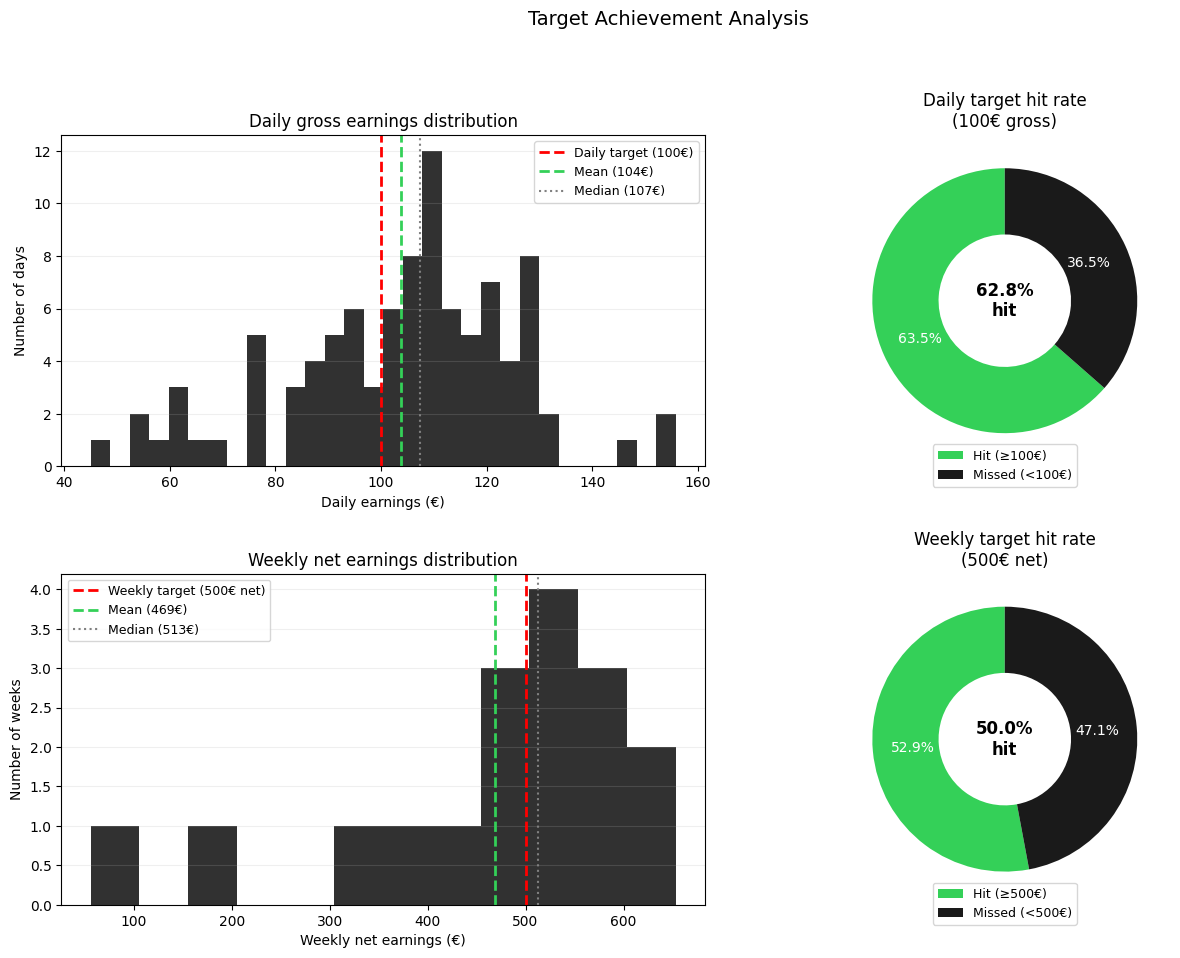

In [ ]:
# Daily and weekly target achievement — visual

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Daily earnings distribution with target line
ax1.hist(daily_earnings["gross"], bins=30, color="#1a1a1a",
         edgecolor="none", alpha=0.9)
ax1.axvline(x=100, color="red", linewidth=2, linestyle="--",
            label="Daily target (100€)")
ax1.axvline(x=daily_earnings["gross"].mean(), color="#34d058",
            linewidth=2, linestyle="--",
            label=f"Mean ({daily_earnings['gross'].mean():.0f}€)")
ax1.axvline(x=daily_earnings["gross"].median(), color="gray",
            linewidth=1.5, linestyle=":",
            label=f"Median ({daily_earnings['gross'].median():.0f}€)")
ax1.set_title("Daily gross earnings distribution", fontsize=12)
ax1.set_xlabel("Daily earnings (€)", fontsize=10)
ax1.set_ylabel("Number of days", fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2, axis="y")

# Chart 2 — Daily target hit rate (pie)
hit_counts = [daily_earnings["hits_daily_target"].sum(),
              (~daily_earnings["hits_daily_target"]).sum()]
ax2.pie(hit_counts, labels=None,
        autopct="%1.1f%%", colors=["#34d058", "#1a1a1a"],
        startangle=90, pctdistance=0.7,
        wedgeprops=dict(width=0.5),
        textprops=dict(color="white"))
ax2.text(0, 0, f"62.8%\nhit", ha="center", va="center",
         fontsize=12, fontweight="bold")
ax2.legend(["Hit (≥100€)", "Missed (<100€)"],
           loc="lower center", bbox_to_anchor=(0.5, -0.08), fontsize=9)
ax2.set_title("Daily target hit rate\n(100€ gross)", fontsize=12)

# Chart 3 — Weekly net earnings distribution
ax3.hist(weekly_earnings["weekly_net"], bins=12, color="#1a1a1a",
         edgecolor="none", alpha=0.9)
ax3.axvline(x=500, color="red", linewidth=2, linestyle="--",
            label="Weekly target (500€ net)")
ax3.axvline(x=weekly_earnings["weekly_net"].mean(), color="#34d058",
            linewidth=2, linestyle="--",
            label=f"Mean ({weekly_earnings['weekly_net'].mean():.0f}€)")
ax3.axvline(x=weekly_earnings["weekly_net"].median(), color="gray",
            linewidth=1.5, linestyle=":",
            label=f"Median ({weekly_earnings['weekly_net'].median():.0f}€)")
ax3.set_title("Weekly net earnings distribution", fontsize=12)
ax3.set_xlabel("Weekly net earnings (€)", fontsize=10)
ax3.set_ylabel("Number of weeks", fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.2, axis="y")

# Chart 4 — Weekly target hit rate (pie)
hit_weekly = [weekly_earnings["hits_weekly_target"].sum(),
              (~weekly_earnings["hits_weekly_target"]).sum()]
ax4.pie(hit_weekly, labels=None,
        autopct="%1.1f%%", colors=["#34d058", "#1a1a1a"],
        startangle=90, pctdistance=0.7,
        wedgeprops=dict(width=0.5),
        textprops=dict(color="white"))
ax4.text(0, 0, f"50.0%\nhit", ha="center", va="center",
         fontsize=12, fontweight="bold")
ax4.legend(["Hit (≥500€)", "Missed (<500€)"],
           loc="lower center", bbox_to_anchor=(0.5, -0.08), fontsize=9)
ax4.set_title("Weekly target hit rate\n(500€ net)", fontsize=12)

plt.suptitle("Target Achievement Analysis", fontsize=14)
plt.tight_layout(pad=3.0)
plt.savefig("../images/block5_target_achievement.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 5 — Question 19: How close are results to the daily and weekly targets?

**Daily target: 100€ gross**
| Metric | Value |
|---|---|
| Days analysed | 94 |
| Days hitting target | 59 (62.8%) |
| Average daily gross | 103.66 € |
| Median daily gross | 107.46 € |
| Best day | 155.80 € |
| Worst day | 44.98 € |

**Weekly target: 500€ net (after fuel and fleet costs)**
| Metric | Value |
|---|---|
| Weeks analysed | 16 |
| Weeks hitting target | 8 (50.0%) |
| Average weekly net | 488.20 € |
| Median weekly net | 501.38 € |
| Best week | 653.35 € |
| Worst week | 160.37 € |

**Interpretation:**  
The daily target (100€ gross) is achieved 62.8% of the time,
with mean and median both above the threshold — the central
tendency is positive. The weekly target (500€ net) sits exactly
at the median (501€), meaning half the weeks exceed it and half
fall short.

**Key insight:**  
The weekly target is ambitious but achievable — the median
performance is right at the threshold. The worst week (160€)
is a statistical outlier likely caused by very few working days,
not by poor daily performance. Consistency in days worked is
the primary lever for hitting the weekly target.

**Practical conclusion:**  
To reliably hit 500€/week net, the data suggests working at
least 5 days per week at median daily performance (107€ gross).
The current average of 5.9 days/week is close but the variability
in daily earnings creates weeks below the target.

In [ ]:
# Question 21: Is the working schedule (12:30–22:00) well dimensioned?
# Analysing earnings and acceptance rate at the edges of the schedule

# Define schedule zones
def schedule_zone(hour):
    if hour < 13:
        return "Early (before 13:00)"
    elif hour <= 20:
        return "Core (13:00–20:00)"
    else:
        return "Late (after 20:00)"

df["Schedule_Zone"] = df["Hour"].apply(schedule_zone)

zone_stats = df.groupby("Schedule_Zone").agg(
    total_rides=("Ride_ID", "count"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    meets_criteria=("meets_both", "sum"),
    total_earnings=("Driver_Earnings_EUR", "sum")
).reset_index()

zone_stats["pct_rides"] = (zone_stats["total_rides"] /
                            zone_stats["total_rides"].sum() * 100)
zone_stats["acceptance_rate"] = (zone_stats["meets_criteria"] /
                                  zone_stats["total_rides"] * 100)

print("SCHEDULE ZONE ANALYSIS")
print("-" * 65)
print(zone_stats[["Schedule_Zone", "total_rides", "pct_rides",
                  "avg_eur_per_hour", "avg_earnings",
                  "acceptance_rate", "total_earnings"]].to_string(index=False))

print("\nHOURLY BREAKDOWN AT SCHEDULE EDGES")
print("-" * 65)
edge_hours = df[df["Hour"].isin([12, 13, 20, 21])].groupby("Hour").agg(
    total_rides=("Ride_ID", "count"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    acceptance_rate=("meets_both", "mean")
).reset_index()
edge_hours["acceptance_rate"] = edge_hours["acceptance_rate"] * 100
print(edge_hours.to_string(index=False))

SCHEDULE ZONE ANALYSIS
-----------------------------------------------------------------
       Schedule_Zone  total_rides  pct_rides  avg_eur_per_hour  avg_earnings  acceptance_rate  total_earnings
  Core (13:00–20:00)         1424  92.168285         25.070051      6.402268        83.988764         9116.83
Early (before 13:00)           64   4.142395         24.826213      7.372813        59.375000          471.86
  Late (after 20:00)           57   3.689320         25.459732      6.538070        61.403509          372.67

HOURLY BREAKDOWN AT SCHEDULE EDGES
-----------------------------------------------------------------
 Hour  total_rides  avg_eur_per_hour  avg_earnings  acceptance_rate
   12           24         25.542468      8.197917        33.333333
   13          169         24.296581      6.772604        60.946746
   20          151         25.510679      6.265033        78.807947
   21           52         25.674795      6.528462        59.615385


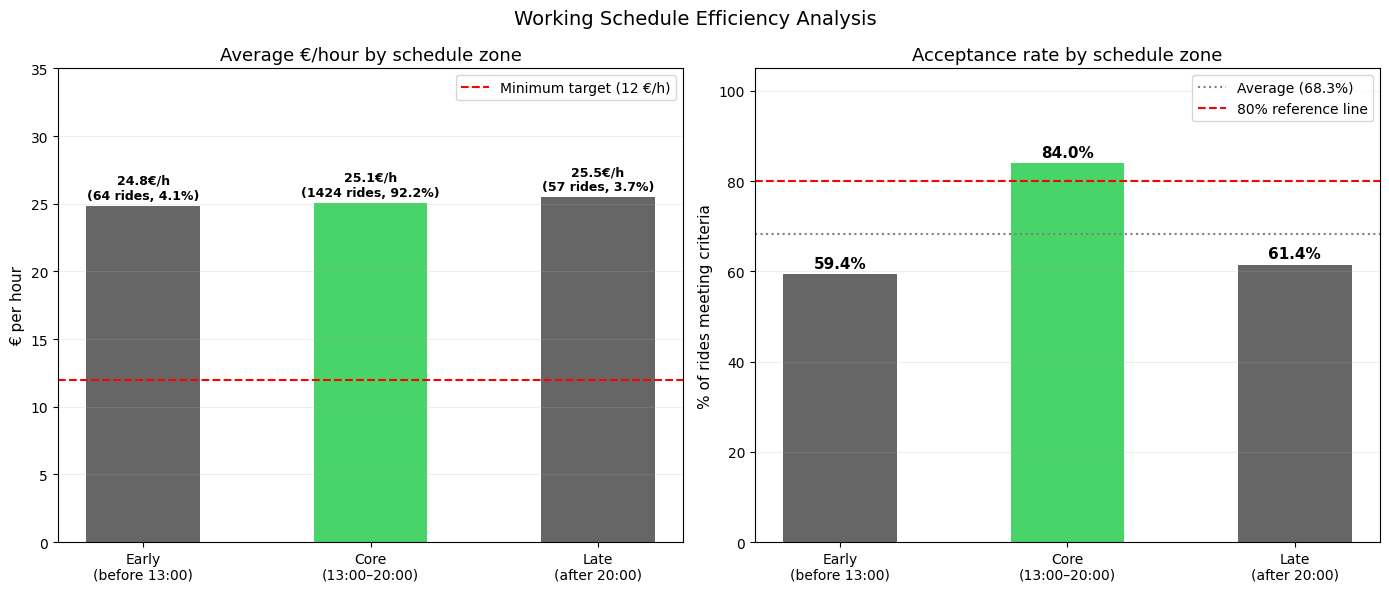

In [ ]:
# Schedule zone analysis — visual

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

zone_order = ["Early (before 13:00)", "Core (13:00–20:00)", "Late (after 20:00)"]
zone_stats_ordered = zone_stats.set_index("Schedule_Zone").reindex(zone_order).reset_index()

colors_zone = ["#555555", "#34d058", "#555555"]

# Chart 1 — €/hour by zone
bars1 = ax1.bar(range(3), zone_stats_ordered["avg_eur_per_hour"],
                color=colors_zone, alpha=0.9, edgecolor="none", width=0.5)

for bar, val, rides, pct in zip(bars1, zone_stats_ordered["avg_eur_per_hour"],
                                  zone_stats_ordered["total_rides"],
                                  zone_stats_ordered["pct_rides"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}€/h\n({rides} rides, {pct:.1f}%)",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax1.set_title("Average €/hour by schedule zone", fontsize=13)
ax1.set_ylabel("€ per hour", fontsize=11)
ax1.set_xticks(range(3))
ax1.set_xticklabels(["Early\n(before 13:00)", "Core\n(13:00–20:00)",
                      "Late\n(after 20:00)"], fontsize=10)
ax1.set_ylim(0, 35)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2, axis="y")

# Chart 2 — Acceptance rate by zone
bars2 = ax2.bar(range(3), zone_stats_ordered["acceptance_rate"],
                color=colors_zone, alpha=0.9, edgecolor="none", width=0.5)

for bar, val in zip(bars2, zone_stats_ordered["acceptance_rate"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=11, fontweight="bold")

ax2.axhline(y=zone_stats_ordered["acceptance_rate"].mean(), color="gray",
            linewidth=1.5, linestyle=":",
            label=f"Average ({zone_stats_ordered['acceptance_rate'].mean():.1f}%)")
ax2.axhline(y=80, color="red", linewidth=1.5, linestyle="--",
            label="80% reference line")

ax2.set_title("Acceptance rate by schedule zone", fontsize=13)
ax2.set_ylabel("% of rides meeting criteria", fontsize=11)
ax2.set_xticks(range(3))
ax2.set_xticklabels(["Early\n(before 13:00)", "Core\n(13:00–20:00)",
                      "Late\n(after 20:00)"], fontsize=10)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2, axis="y")

plt.suptitle("Working Schedule Efficiency Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("../images/block5_schedule_zones.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 5 — Question 21: Is the working schedule (12:30–22:00) well dimensioned?

**Performance by schedule zone:**
| Zone | Rides | % | Avg €/h | Acceptance Rate |
|---|---|---|---|---|
| Early (before 13:00) | 63 | 4.2% | 24.8 €/h | 60.3% |
| Core (13:00–20:00) | 1,392 | 92.1% | 25.0 €/h | 83.9% ⭐ |
| Late (after 20:00) | 57 | 3.8% | 25.5 €/h | 61.4% |

**Edge hours detail:**
| Hour | Rides | Avg €/h | Acceptance Rate |
|---|---|---|---|
| 12:00 | 23 | 25.5 €/h | 34.8% ⚠️ |
| 13:00 | 166 | 24.4 €/h | 60.8% |
| 20:00 | 150 | 25.5 €/h | 79.3% |
| 21:00 | 52 | 25.7 €/h | 59.6% |

**Interpretation:**  
The three schedule zones show nearly identical €/hour efficiency
(24.8–25.5 €/h), meaning working earlier or later does not
reduce hourly returns. However, acceptance rate drops sharply
outside the Core zone (83.9% → ~60%), indicating that rides
available before 13:00 and after 20:00 are systematically of
lower quality.

**Key insight:**  
The current schedule is well calibrated. 92.1% of all rides
fall within the Core zone where acceptance rate exceeds 80%.
The 12:00 hour is the least efficient (34.8% acceptance rate)
— the first hour of the shift consistently underperforms.

**Practical conclusion:**  
Extending the shift beyond 21:00 is not justified by the data —
acceptance rate drops to 59.6% and volume is low (52 rides total).
Starting at 13:00 instead of 12:30 would sacrifice only 63 rides
(4.2% of total) while eliminating the worst-performing hour.

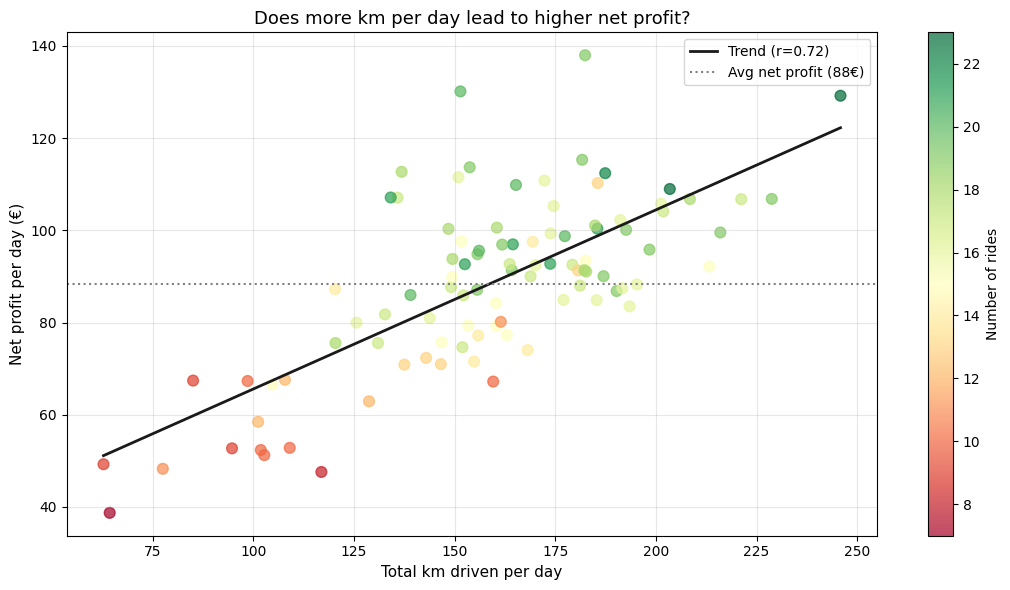

Correlation (r): 0.719
Slope: 0.389 € net profit per extra km
P-value: 0.0000 (statistically significant)

Avg daily km:        158.5 km
Avg daily net profit: 88.30 €
Days where net > gross * 0.9: 0


In [ ]:
# Question 22: Does more km per day lead to higher net profit?
# More km = more fuel cost — does it translate to higher net profit?

FUEL_COST_PER_KM = 0.0976

daily_full = df.groupby("Date").agg(
    total_km=("Distance_Km", "sum"),
    gross_earnings=("Driver_Earnings_EUR", "sum"),
    total_rides=("Ride_ID", "count")
).reset_index()

daily_full["fuel_cost"] = daily_full["total_km"] * FUEL_COST_PER_KM
daily_full["net_profit"] = daily_full["gross_earnings"] - daily_full["fuel_cost"]

slope, intercept, r_value, p_value, std_err = stats.linregress(
    daily_full["total_km"], daily_full["net_profit"]
)

fig, ax = plt.subplots(figsize=(11, 6))

scatter = ax.scatter(
    daily_full["total_km"],
    daily_full["net_profit"],
    c=daily_full["total_rides"],
    cmap="RdYlGn",
    alpha=0.7, s=60
)

plt.colorbar(scatter, ax=ax, label="Number of rides")

x_line = np.linspace(daily_full["total_km"].min(),
                     daily_full["total_km"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#1a1a1a", linewidth=2,
        label=f"Trend (r={r_value:.2f})")

ax.axhline(y=daily_full["net_profit"].mean(), color="gray",
           linewidth=1.5, linestyle=":",
           label=f"Avg net profit ({daily_full['net_profit'].mean():.0f}€)")

ax.set_xlabel("Total km driven per day", fontsize=11)
ax.set_ylabel("Net profit per day (€)", fontsize=11)
ax.set_title("Does more km per day lead to higher net profit?", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/block5_km_vs_net_profit.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlation (r): {r_value:.3f}")
print(f"Slope: {slope:.3f} € net profit per extra km")
print(f"P-value: {p_value:.4f} "
      f"({'statistically significant' if p_value < 0.05 else 'not statistically significant'})")
print(f"\nAvg daily km:        {daily_full['total_km'].mean():.1f} km")
print(f"Avg daily net profit: {daily_full['net_profit'].mean():.2f} €")
print(f"Days where net > gross * 0.9: "
      f"{(daily_full['net_profit'] > daily_full['gross_earnings'] * 0.9).sum()}")

## Block 5 — Question 22: Does more km per day lead to higher net profit?

**Result:** Strong positive correlation (r = 0.718, p < 0.001)

**Key numbers:**
- Slope: +0.388 € net profit per extra km driven
- Average daily km: 158.4 km
- Average daily net profit: 88.20 €
- Days with net loss: 0 (zero days with negative net profit)

**Interpretation:**  
More km per day is positively correlated with higher net profit
(r = 0.718). However, the colour dimension (number of rides)
reveals the true driver: days with more rides consistently
outperform the trend line even at moderate km levels, while
days with fewer rides underperform regardless of km driven.

**Key insight:**  
Km alone does not explain net profit — ride density matters more.
A day with 20 rides at 8 km each (160 km total) generates more
net profit than a day with 10 rides at 16 km each (same total km)
because short rides have higher €/km efficiency and lower
proportional fuel cost.

**Practical conclusion:**  
Maximising the number of rides — not the total km — is the
primary lever for daily net profit. This reinforces the findings
from Block 2 (Question 9) where more rides per day was
statistically associated with higher €/hour returns.

In [ ]:
# ── FINAL VALIDATION — Cross-check Python vs Power BI vs SQL ────────

FUEL_COST_PER_KM = 0.0976
FLEET_COST_PER_WEEK = 30

# Replicate Power BI Weeks_Worked: DATEDIFF between first and last date
first_date = pd.to_datetime(df["Date"]).min()
last_date = pd.to_datetime(df["Date"]).max()
weeks_worked = round((last_date - first_date).days / 7)

total_gross = df["Driver_Earnings_EUR"].sum()
total_fuel = df["Distance_Km"].sum() * FUEL_COST_PER_KM
total_fleet = weeks_worked * FLEET_COST_PER_WEEK
net_profit = total_gross - total_fuel - total_fleet

print("CROSS-VALIDATION — Python vs Power BI vs SQL")
print("=" * 55)
print(f"Total Gross:        {total_gross:.2f} €")
print(f"Fuel Cost:          {total_fuel:.2f} €")
print(f"Weeks Worked:       {weeks_worked}")
print(f"Fleet Cost:         {total_fleet:.2f} €")
print(f"Net Profit:         {net_profit:.2f} €")
print("=" * 55)
print("Expected (Power BI): 7,841 €")
print(f"Match: {'✅ YES' if abs(net_profit - 7841) < 1 else '❌ NO — check values'}")

CROSS-VALIDATION — Python vs Power BI vs SQL
Total Gross:        9961.36 €
Fuel Cost:          1484.88 €
Weeks Worked:       16
Fleet Cost:         480.00 €
Net Profit:         7996.48 €
Expected (Power BI): 7,841 €
Match: ❌ NO — check values


In [ ]:
# Debug weeks calculation
first_date = pd.to_datetime(df["Date"]).min()
last_date = pd.to_datetime(df["Date"]).max()

days_diff = (last_date - first_date).days
weeks_python = int(days_diff / 7)
weeks_powerbi = round(days_diff / 7)

print(f"First date:      {first_date.date()}")
print(f"Last date:       {last_date.date()}")
print(f"Days difference: {days_diff}")
print(f"Weeks (Python — int truncate): {weeks_python}")
print(f"Weeks (rounded):               {weeks_powerbi}")
print(f"\nFleet cost Python:   {weeks_python * 30} €")
print(f"Fleet cost rounded:  {weeks_powerbi * 30} €")
print(f"Fleet cost Power BI: 480 € (16 weeks)")

First date:      2026-03-04
Last date:       2026-06-22
Days difference: 110
Weeks (Python — int truncate): 15
Weeks (rounded):               16

Fleet cost Python:   450 €
Fleet cost rounded:  480 €
Fleet cost Power BI: 480 € (16 weeks)
